# 05 — Selected-stratum simulator design + synthetic SBI prep

Notebook 04 established the broad, leakage-free baseline and identified green/yellow SBI-ready strata. The top recommended stratum was:

```text
study_id:        CEDIRANIB_HORIZONIII
arm:             FOLFOX + bevacizumab 5mg/kg
drug class hint: anti-angiogenic / vascular-support model
```

This notebook is the bridge from **cohort readiness** to **synthetic SBI training**.

It does **not** train SBI yet. Instead, it creates a stratum-specific simulation design that future SBI can use.

Main goals:

1. Extract the selected real clinical stratum.
2. Rebuild its scan schedules, dose schedules, baseline tumor-size distribution, and empirical observation-noise distribution.
3. Compare two mechanistic simulator families:
   - cytotoxic/transit-damage Simeoni TGI;
   - anti-angiogenic carrying-capacity TGI.
4. Generate prior-predictive synthetic trajectories using real scan/dose templates.
5. Save padded arrays and parameter tables suitable for a future NPE/SBI notebook.
6. Compare synthetic summaries to real stratum summaries.

The key idea is:

> Synthetic SBI should mimic a selected real clinical stratum, not an abstract toy patient.

In [1]:
from __future__ import annotations

import json
import math
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import display

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


# ---------------------------------------------------------------------
# Robust project/output path detection
# ---------------------------------------------------------------------

START = Path.cwd().resolve()


def find_project_root(start: Path) -> Path:
    """Prefer the repo root, not the notebooks folder."""
    candidates = [start, *start.parents]

    for p in candidates:
        if (p / "outputs" / "notebook_04_cohort_scale_baselines").exists():
            return p

    for p in candidates:
        if (p / "outputs" / "notebook_00_audit_and_fit" / "ALL_observations.csv").exists():
            return p

    for p in candidates:
        if (p / "data").exists() and (p / "outputs").exists():
            return p

    return start


PROJECT_ROOT = find_project_root(START)

DISCOVERY_OUT_DIR = PROJECT_ROOT / "outputs" / "notebook_00_audit_and_fit"
BASELINE_OUT_DIR = PROJECT_ROOT / "outputs" / "notebook_04_cohort_scale_baselines"

OUT_DIR = PROJECT_ROOT / "outputs" / "notebook_05_selected_stratum_simulator_design"
PLOT_DIR = OUT_DIR / "plots"
SYNTH_OUT_DIR = OUT_DIR / "synthetic_data"

OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
SYNTH_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("START:            ", START)
print("PROJECT_ROOT:     ", PROJECT_ROOT)
print("DISCOVERY_OUT_DIR:", DISCOVERY_OUT_DIR)
print("BASELINE_OUT_DIR: ", BASELINE_OUT_DIR)
print("OUT_DIR:          ", OUT_DIR)

START:             C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\notebooks
PROJECT_ROOT:      C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd
DISCOVERY_OUT_DIR: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_00_audit_and_fit
BASELINE_OUT_DIR:  C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_04_cohort_scale_baselines
OUT_DIR:           C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design


In [2]:
# ---------------------------------------------------------------------
# Load canonical data and notebook 04 outputs
# ---------------------------------------------------------------------

obs_path = DISCOVERY_OUT_DIR / "ALL_observations.csv"
dose_path = DISCOVERY_OUT_DIR / "ALL_doses.csv"
cohort_path = BASELINE_OUT_DIR / "forecasting_cohort.csv"
readiness_path = BASELINE_OUT_DIR / "recommended_sbi_starter_strata.csv"
rolling_path = BASELINE_OUT_DIR / "empirical_rolling_predictions_long.csv"
calibrated_path = BASELINE_OUT_DIR / "leakage_free_calibrated_empirical_predictions_long.csv"

required_paths = [obs_path, dose_path, cohort_path, readiness_path, rolling_path]
missing_paths = [str(p) for p in required_paths if not p.exists()]

if missing_paths:
    raise FileNotFoundError(
        "Missing required files. Run notebooks 00 and 04 first.\n"
        + "\n".join(missing_paths)
    )

all_obs = pd.read_csv(obs_path, dtype={"study_id": str, "patient_id": str})
all_doses = pd.read_csv(dose_path, dtype={"study_id": str, "patient_id": str})
forecasting_cohort = pd.read_csv(cohort_path, dtype={"study_id": str, "patient_id": str})
starter_strata = pd.read_csv(readiness_path, dtype={"study_id": str})
rolling_empirical = pd.read_csv(rolling_path, dtype={"study_id": str, "patient_id": str})

if calibrated_path.exists():
    calibrated_empirical = pd.read_csv(calibrated_path, dtype={"study_id": str, "patient_id": str})
else:
    calibrated_empirical = pd.DataFrame()

for df in [all_obs, all_doses, forecasting_cohort, starter_strata, rolling_empirical, calibrated_empirical]:
    if len(df) and "study_id" in df.columns:
        df["study_id"] = df["study_id"].astype(str).str.strip()
    if len(df) and "patient_id" in df.columns:
        df["patient_id"] = df["patient_id"].astype(str).str.strip()

print("Observations:        ", all_obs.shape)
print("Doses:               ", all_doses.shape)
print("Forecasting cohort:  ", forecasting_cohort.shape)
print("Starter strata:      ", starter_strata.shape)
print("Rolling empirical:   ", rolling_empirical.shape)
print("Calibrated empirical:", calibrated_empirical.shape)

display(starter_strata.head(10))

Observations:         (28562, 9)
Doses:                (352854, 8)
Forecasting cohort:   (1923, 25)
Starter strata:       (16, 20)
Rolling empirical:    (23130, 26)
Calibrated empirical: (231300, 53)


,study_id,drug_signature,arm,model_family_hint,n_patients,median_n_scans,median_duration_days,median_gap_days,dose_available_frac,response_then_regrowth_frac,response_or_shrinkage_frac,progression_or_growth_frac,n_predictions,baseline_rmse,baseline_median_abs_log_error,baseline_coverage_80,baseline_coverage_90,baseline_width_log_80,sbi_readiness,readiness_reason
0,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,anti_angiogenic_or_vascular_support_model,268,6.0,362.0,64.0,1.0,0.324627,0.458955,0.018657,772,0.297332,0.110457,0.814767,0.931347,0.519931,green,sufficient_for_next_experiment
1,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,cytotoxic_transit_damage_TGI,190,7.0,372.5,57.5,1.0,0.457895,0.389474,0.042105,907,0.361455,0.102370,0.780595,0.890849,0.519931,green,sufficient_for_next_experiment
2,EFC10262,5-FU+IRINOTECAN+LEUCOVORIN+PLACEBO,Placebo + FOLFIRI regimen,cytotoxic_transit_damage_TGI,190,8.0,302.0,42.0,1.0,0.231579,0.184211,0.184211,850,0.357746,0.065803,0.870588,0.931765,0.520053,green,sufficient_for_next_experiment
3,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFOX,cytotoxic_transit_damage_TGI,188,8.0,420.0,57.0,1.0,0.452128,0.430851,0.021277,982,0.373710,0.115288,0.754582,0.866599,0.519751,green,sufficient_for_next_experiment
4,DATASET_263,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFIRI,cytotoxic_transit_damage_TGI,152,7.0,359.0,56.0,1.0,0.460526,0.282895,0.111842,646,0.305638,0.102753,0.806502,0.914861,0.519931,green,sufficient_for_next_experiment
5,A6181122,FLUOROURACIL+FOLINIC ACID/VITAMIN K+IRINOTECAN...,UNKNOWN_ARM,cytotoxic_transit_damage_TGI,127,8.0,338.0,43.0,1.0,0.330709,0.354331,0.031496,593,0.330668,0.093786,0.836425,0.910624,0.520040,green,sufficient_for_next_experiment
6,EFC5505,5-FU BOLUS+5-FU INFUSION+LEUCOVORIN+OXALIPLATI...,PLACEBO,cytotoxic_transit_damage_TGI,120,7.0,365.0,61.0,1.0,0.300000,0.525000,0.050000,365,0.498425,0.131535,0.775342,0.876712,0.519931,green,sufficient_for_next_experiment
7,DATASET_263,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFIRI alone,cytotoxic_transit_damage_TGI,104,7.0,328.5,56.5,1.0,0.298077,0.182692,0.163462,388,0.335119,0.090526,0.811856,0.907216,0.519931,green,sufficient_for_next_experiment
8,EFC4972,5-FU BOLUS+5-FU INFUSION+LEUCOVORIN+OXALIPLATIN,PLACEBO,cytotoxic_transit_damage_TGI,74,7.0,352.0,61.0,1.0,0.432432,0.391892,0.027027,220,0.705271,0.193146,0.586364,0.736364,0.519661,yellow,sufficient_for_next_experiment
9,AMGEN_20040249,5-FLUOROURACIL 46 HOUR+5-FLUOROURACIL BOLUS+BE...,bevacizumab with chemotherapy,anti_angiogenic_or_vascular_support_model,67,7.0,497.0,84.0,1.0,0.283582,0.582090,0.044776,240,0.227807,0.122271,0.841667,0.950000,0.519931,yellow,sufficient_for_next_experiment


## Select the target stratum

By default, this notebook uses the best green stratum from notebook 04:

```text
CEDIRANIB_HORIZONIII
FOLFOX + bevacizumab 5mg/kg
```

You can override the target manually in the next cell. If the exact manual stratum is not found, the notebook falls back to the first recommended green/yellow stratum.

In [3]:
# ---------------------------------------------------------------------
# Target stratum configuration
# ---------------------------------------------------------------------

TARGET_STUDY_ID = "CEDIRANIB_HORIZONIII"
TARGET_DRUG_SIGNATURE = "FOLFOX + BEVACIZUMAB 5MG/KG"
TARGET_ARM = "FOLFOX + bevacizumab 5mg/kg"

USE_MANUAL_TARGET = True


def select_target_stratum(starter: pd.DataFrame, manual: bool = True) -> pd.Series:
    if manual:
        mask = (
            (starter["study_id"].astype(str).str.strip() == TARGET_STUDY_ID)
            & (starter["drug_signature"].astype(str).str.strip() == TARGET_DRUG_SIGNATURE)
            & (starter["arm"].astype(str).str.strip() == TARGET_ARM)
        )
        if mask.any():
            return starter[mask].iloc[0]

    tmp = starter.copy()
    order = {"green": 0, "yellow": 1, "red": 2}
    if "sbi_readiness" in tmp.columns:
        tmp["_order"] = tmp["sbi_readiness"].map(order).fillna(9)
    else:
        tmp["_order"] = 9

    tmp = tmp.sort_values(
        ["_order", "n_patients", "n_predictions"],
        ascending=[True, False, False],
    )

    return tmp.iloc[0].drop(labels=["_order"], errors="ignore")


target = select_target_stratum(starter_strata, manual=USE_MANUAL_TARGET)

print("Selected target stratum:")
print(target.to_dict())

target_path = OUT_DIR / "selected_target_stratum.json"
with open(target_path, "w") as f:
    json.dump(target.to_dict(), f, indent=2, default=str)

print("Saved:", target_path)

Selected target stratum:
{'study_id': 'CEDIRANIB_HORIZONIII', 'drug_signature': 'FOLFOX + BEVACIZUMAB 5MG/KG', 'arm': 'FOLFOX + bevacizumab 5mg/kg', 'model_family_hint': 'anti_angiogenic_or_vascular_support_model', 'n_patients': 268, 'median_n_scans': 6.0, 'median_duration_days': 362.0, 'median_gap_days': 64.0, 'dose_available_frac': 1.0, 'response_then_regrowth_frac': 0.3246268656716418, 'response_or_shrinkage_frac': 0.458955223880597, 'progression_or_growth_frac': 0.0186567164179104, 'n_predictions': 772, 'baseline_rmse': 0.2973319777078372, 'baseline_median_abs_log_error': 0.1104573223295606, 'baseline_coverage_80': 0.8147668393782384, 'baseline_coverage_90': 0.9313471502590672, 'baseline_width_log_80': 0.5199307702521858, 'sbi_readiness': 'green', 'readiness_reason': 'sufficient_for_next_experiment'}
Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\selected_target_stratum.json


In [4]:
# ---------------------------------------------------------------------
# Extract target patient cohort
# ---------------------------------------------------------------------

target_study = str(target["study_id"])
target_drug_signature = str(target["drug_signature"])
target_arm = str(target["arm"])

target_patients = forecasting_cohort[
    (forecasting_cohort["study_id"].astype(str) == target_study)
    & (forecasting_cohort["drug_signature"].astype(str) == target_drug_signature)
    & (forecasting_cohort["arm"].astype(str) == target_arm)
].copy()

if target_patients.empty:
    raise RuntimeError(
        "Target stratum has no patients in forecasting_cohort.csv. "
        "Check target_study, target_drug_signature, and target_arm."
    )

target_patient_keys = set(target_patients["patient_key"].astype(str))

target_obs = all_obs[
    (all_obs["study_id"].astype(str) == target_study)
    & ((all_obs["study_id"].astype(str) + "__" + all_obs["patient_id"].astype(str)).isin(target_patient_keys))
].copy()

target_doses = all_doses[
    (all_doses["study_id"].astype(str) == target_study)
    & ((all_doses["study_id"].astype(str) + "__" + all_doses["patient_id"].astype(str)).isin(target_patient_keys))
].copy()

target_rolling = rolling_empirical[
    (rolling_empirical["study_id"].astype(str) == target_study)
    & (rolling_empirical["patient_key"].astype(str).isin(target_patient_keys))
].copy()

target_patients_path = OUT_DIR / "selected_stratum_patients.csv"
target_obs_path = OUT_DIR / "selected_stratum_observations.csv"
target_doses_path = OUT_DIR / "selected_stratum_doses.csv"

target_patients.to_csv(target_patients_path, index=False)
target_obs.to_csv(target_obs_path, index=False)
target_doses.to_csv(target_doses_path, index=False)

print("Target patients:", target_patients.shape)
print("Target observations:", target_obs.shape)
print("Target doses:", target_doses.shape)
print("Target rolling empirical:", target_rolling.shape)

print("Saved:")
print(" ", target_patients_path)
print(" ", target_obs_path)
print(" ", target_doses_path)

display(target_patients.head())
display(target_obs.head())
display(target_doses.head())

Target patients: (268, 25)
Target observations: (1844, 9)
Target doses: (25422, 8)
Target rolling empirical: (2316, 26)
Saved:
  C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\selected_stratum_patients.csv
  C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\selected_stratum_observations.csv
  C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\selected_stratum_doses.csv


,study_id,patient_id,patient_key,arm,n_scans,duration_days,first_raw_time_days,last_raw_time_days,median_gap_days,max_gap_days,...,response_class,n_collapsed_duplicate_rows,eligible_basic,n_dose_rows,n_drugs,drug_signature,dose_time_min,dose_time_max,dose_span_days,model_family_hint
66,CEDIRANIB_HORIZONIII,337.0,CEDIRANIB_HORIZONIII__337.0,FOLFOX + bevacizumab 5mg/kg,14,933.0,-13.0,920.0,63.0,110.0,...,response_or_shrinkage,0,True,162,1,FOLFOX + BEVACIZUMAB 5MG/KG,0.0,952.0,952.0,anti_angiogenic_or_vascular_support_model
74,CEDIRANIB_HORIZONIII,235.0,CEDIRANIB_HORIZONIII__235.0,FOLFOX + bevacizumab 5mg/kg,14,754.0,-7.0,747.0,56.0,91.0,...,response_or_shrinkage,0,True,100,1,FOLFOX + BEVACIZUMAB 5MG/KG,0.0,754.0,754.0,anti_angiogenic_or_vascular_support_model
101,CEDIRANIB_HORIZONIII,592.0,CEDIRANIB_HORIZONIII__592.0,FOLFOX + bevacizumab 5mg/kg,13,678.0,-6.0,672.0,56.5,62.0,...,response_then_regrowth,0,True,208,1,FOLFOX + BEVACIZUMAB 5MG/KG,0.0,721.0,721.0,anti_angiogenic_or_vascular_support_model
125,CEDIRANIB_HORIZONIII,251.0,CEDIRANIB_HORIZONIII__251.0,FOLFOX + bevacizumab 5mg/kg,12,853.0,-13.0,840.0,84.0,85.0,...,stable_like,0,True,80,1,FOLFOX + BEVACIZUMAB 5MG/KG,0.0,629.0,629.0,anti_angiogenic_or_vascular_support_model
177,CEDIRANIB_HORIZONIII,382.0,CEDIRANIB_HORIZONIII__382.0,FOLFOX + bevacizumab 5mg/kg,11,773.0,-7.0,766.0,83.5,92.0,...,response_or_shrinkage,0,True,158,1,FOLFOX + BEVACIZUMAB 5MG/KG,0.0,630.0,630.0,anti_angiogenic_or_vascular_support_model


,study_id,patient_id,raw_day,time_days,sld_mm,rel_sld,baseline_sld_mm,n_lesions,arm
21421,CEDIRANIB_HORIZONIII,10.0,-5.0,-5.0,3.5,1.000000,3.5,1,FOLFOX + bevacizumab 5mg/kg
21422,CEDIRANIB_HORIZONIII,10.0,60.0,60.0,2.5,0.714286,3.5,1,FOLFOX + bevacizumab 5mg/kg
21423,CEDIRANIB_HORIZONIII,10.0,88.0,88.0,2.3,0.657143,3.5,1,FOLFOX + bevacizumab 5mg/kg
21424,CEDIRANIB_HORIZONIII,10.0,116.0,116.0,2.3,0.657143,3.5,1,FOLFOX + bevacizumab 5mg/kg
21425,CEDIRANIB_HORIZONIII,10.0,182.0,182.0,2.8,0.800000,3.5,1,FOLFOX + bevacizumab 5mg/kg


,study_id,patient_id,raw_day,time_days,drug,dose_amount,dose_unit,arm
239499,CEDIRANIB_HORIZONIII,10.0,1.0,0.0,FOLFOX + bevacizumab 5mg/kg,NaN,NaN,FOLFOX + bevacizumab 5mg/kg
239500,CEDIRANIB_HORIZONIII,10.0,1.0,0.0,FOLFOX + bevacizumab 5mg/kg,494.0,NaN,FOLFOX + bevacizumab 5mg/kg
239501,CEDIRANIB_HORIZONIII,10.0,1.0,0.0,FOLFOX + bevacizumab 5mg/kg,NaN,NaN,FOLFOX + bevacizumab 5mg/kg
239502,CEDIRANIB_HORIZONIII,10.0,1.0,0.0,FOLFOX + bevacizumab 5mg/kg,NaN,NaN,FOLFOX + bevacizumab 5mg/kg
239503,CEDIRANIB_HORIZONIII,10.0,15.0,14.0,FOLFOX + bevacizumab 5mg/kg,NaN,NaN,FOLFOX + bevacizumab 5mg/kg


## Clinical trajectory helpers

We use the same basic preprocessing logic as earlier notebooks:

1. keep positive finite relative SLD;
2. collapse duplicate scan days by median;
3. shift time so the first scan is `t=0`;
4. renormalize relative SLD so the first selected scan is exactly `1`.

The synthetic simulator will copy real scan schedules from this selected stratum.

In [5]:
# ---------------------------------------------------------------------
# Patient trajectory helpers
# ---------------------------------------------------------------------

def _to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")


def patient_key(study_id: str, patient_id: str) -> str:
    return f"{study_id}__{patient_id}"


def collapse_patient_observations(p_obs: pd.DataFrame) -> pd.DataFrame:
    df = p_obs.copy()

    df["time_days"] = _to_num(df["time_days"])
    df["rel_sld"] = _to_num(df["rel_sld"])

    if "sld_mm" in df.columns:
        df["sld_mm"] = _to_num(df["sld_mm"])
    else:
        df["sld_mm"] = np.nan

    if "baseline_sld_mm" in df.columns:
        df["baseline_sld_mm"] = _to_num(df["baseline_sld_mm"])
    else:
        df["baseline_sld_mm"] = np.nan

    df = df[
        df["time_days"].notna()
        & df["rel_sld"].notna()
        & (df["rel_sld"] > 0)
    ].copy()

    if df.empty:
        return df

    out = (
        df.groupby("time_days", as_index=False)
        .agg(
            rel_sld=("rel_sld", "median"),
            sld_mm=("sld_mm", "median"),
            baseline_sld_mm=("baseline_sld_mm", "first"),
            n_rows_collapsed=("rel_sld", "size"),
        )
        .sort_values("time_days")
        .reset_index(drop=True)
    )

    out["time_since_first_scan"] = out["time_days"] - float(out["time_days"].iloc[0])
    out["rel_sld_renormalized"] = out["rel_sld"] / max(float(out["rel_sld"].iloc[0]), 1e-8)

    return out


def get_patient_observations(study_id: str, patient_id: str) -> pd.DataFrame:
    mask = (
        (target_obs["study_id"].astype(str) == str(study_id))
        & (target_obs["patient_id"].astype(str) == str(patient_id))
    )
    return target_obs.loc[mask].copy()


def get_patient_doses(study_id: str, patient_id: str) -> pd.DataFrame:
    mask = (
        (target_doses["study_id"].astype(str) == str(study_id))
        & (target_doses["patient_id"].astype(str) == str(patient_id))
    )
    return target_doses.loc[mask].copy()


def response_class_from_rel(rel: np.ndarray) -> str:
    rel = np.asarray(rel, dtype=float)
    if len(rel) == 0 or not np.all(np.isfinite(rel)):
        return "unknown"

    min_rel = float(np.min(rel))
    max_rel = float(np.max(rel))
    final_rel = float(rel[-1])

    ever_response = min_rel <= 0.70
    ever_progression = max_rel >= 1.20 or final_rel >= 1.20

    if ever_response and final_rel > min_rel * 1.25:
        return "response_then_regrowth"
    if ever_response:
        return "response_or_shrinkage"
    if ever_progression:
        return "progression_or_growth"
    return "stable_like"


def trajectory_summary(times: np.ndarray, rel: np.ndarray) -> dict:
    times = np.asarray(times, dtype=float)
    rel = np.asarray(rel, dtype=float)
    gaps = np.diff(times)

    return {
        "n_scans": int(len(times)),
        "duration_days": float(times[-1] - times[0]) if len(times) else np.nan,
        "median_gap_days": float(np.median(gaps)) if len(gaps) else np.nan,
        "max_gap_days": float(np.max(gaps)) if len(gaps) else np.nan,
        "min_rel_sld": float(np.min(rel)) if len(rel) else np.nan,
        "max_rel_sld": float(np.max(rel)) if len(rel) else np.nan,
        "final_rel_sld": float(rel[-1]) if len(rel) else np.nan,
        "response_class": response_class_from_rel(rel),
    }


real_traj_rows = []
real_templates = []

for _, row in target_patients.iterrows():
    sid = str(row["study_id"])
    pid = str(row["patient_id"])
    pk = patient_key(sid, pid)

    clean = collapse_patient_observations(get_patient_observations(sid, pid))
    if len(clean) < 2:
        continue

    times = clean["time_since_first_scan"].to_numpy(dtype=float)
    rel = clean["rel_sld_renormalized"].to_numpy(dtype=float)

    summ = trajectory_summary(times, rel)
    summ.update({
        "study_id": sid,
        "patient_id": pid,
        "patient_key": pk,
        "baseline_sld_mm": float(clean["baseline_sld_mm"].dropna().iloc[0]) if clean["baseline_sld_mm"].notna().any() else np.nan,
    })
    real_traj_rows.append(summ)

    real_templates.append({
        "study_id": sid,
        "patient_id": pid,
        "patient_key": pk,
        "times": times,
        "rel": rel,
        "baseline_sld_mm": summ["baseline_sld_mm"],
    })

real_traj_summary = pd.DataFrame(real_traj_rows)

real_traj_summary_path = OUT_DIR / "selected_stratum_real_trajectory_summary.csv"
real_traj_summary.to_csv(real_traj_summary_path, index=False)

print("Real trajectory templates:", len(real_templates))
print("Saved:", real_traj_summary_path)
display(real_traj_summary.head())
display(real_traj_summary["response_class"].value_counts(normalize=True).to_frame("fraction"))

Real trajectory templates: 268
Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\selected_stratum_real_trajectory_summary.csv


,n_scans,duration_days,median_gap_days,max_gap_days,min_rel_sld,max_rel_sld,final_rel_sld,response_class,study_id,patient_id,patient_key,baseline_sld_mm
0,14,933.0,63.0,110.0,0.144578,1.0,0.144578,response_or_shrinkage,CEDIRANIB_HORIZONIII,337.0,CEDIRANIB_HORIZONIII__337.0,8.3
1,14,754.0,56.0,91.0,0.529412,1.0,0.529412,response_or_shrinkage,CEDIRANIB_HORIZONIII,235.0,CEDIRANIB_HORIZONIII__235.0,11.9
2,13,678.0,56.5,62.0,0.355072,1.0,0.485507,response_then_regrowth,CEDIRANIB_HORIZONIII,592.0,CEDIRANIB_HORIZONIII__592.0,13.8
3,12,853.0,84.0,85.0,0.909091,1.0,0.909091,stable_like,CEDIRANIB_HORIZONIII,251.0,CEDIRANIB_HORIZONIII__251.0,1.1
4,11,773.0,83.5,92.0,0.166667,1.0,0.166667,response_or_shrinkage,CEDIRANIB_HORIZONIII,382.0,CEDIRANIB_HORIZONIII__382.0,9.6


,fraction
response_class,
response_or_shrinkage,0.458955
response_then_regrowth,0.324627
stable_like,0.197761
progression_or_growth,0.018657


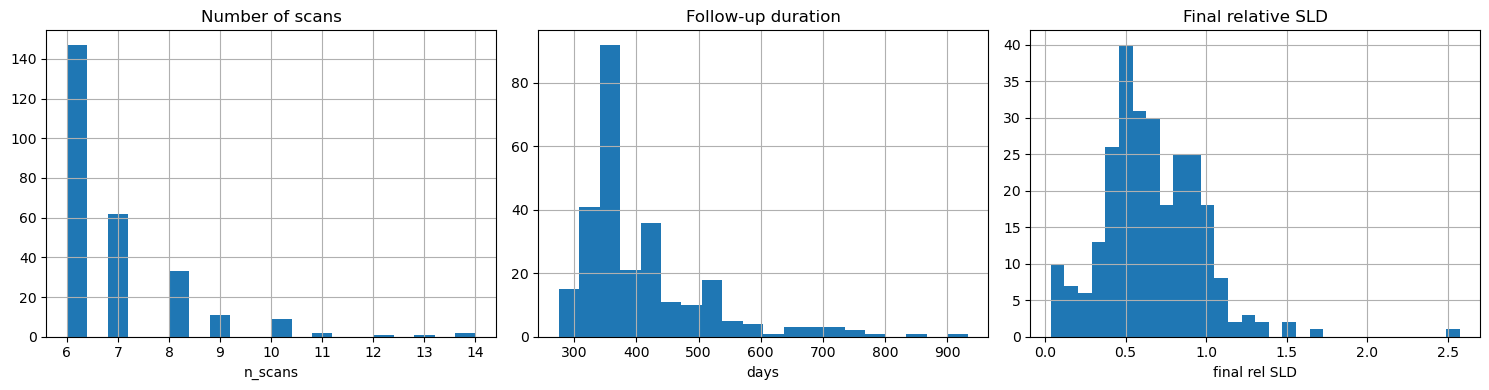

Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\plots\selected_stratum_real_summary_histograms.png


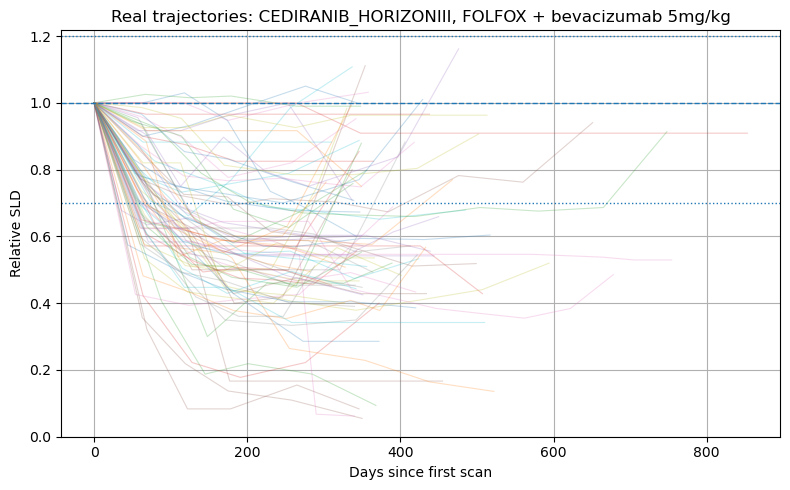

Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\plots\selected_stratum_real_trajectory_overlay.png


In [6]:
# ---------------------------------------------------------------------
# Real stratum summary plots
# ---------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(real_traj_summary["n_scans"].dropna(), bins=20)
axes[0].set_title("Number of scans")
axes[0].set_xlabel("n_scans")

axes[1].hist(real_traj_summary["duration_days"].dropna(), bins=20)
axes[1].set_title("Follow-up duration")
axes[1].set_xlabel("days")

axes[2].hist(real_traj_summary["final_rel_sld"].dropna(), bins=30)
axes[2].set_title("Final relative SLD")
axes[2].set_xlabel("final rel SLD")

fig.tight_layout()
path = PLOT_DIR / "selected_stratum_real_summary_histograms.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", path)


# Overlay a sample of real trajectories.
rng = np.random.default_rng(123)
n_plot = min(80, len(real_templates))
idx = rng.choice(len(real_templates), size=n_plot, replace=False)

fig, ax = plt.subplots(figsize=(8, 5))
for i in idx:
    t = real_templates[i]["times"]
    y = real_templates[i]["rel"]
    ax.plot(t, y, linewidth=0.8, alpha=0.25)

ax.axhline(1.0, linestyle="--", linewidth=1)
ax.axhline(0.7, linestyle=":", linewidth=1)
ax.axhline(1.2, linestyle=":", linewidth=1)
ax.set_xlabel("Days since first scan")
ax.set_ylabel("Relative SLD")
ax.set_title(f"Real trajectories: {target_study}, {target_arm}")
ax.set_ylim(bottom=0)
fig.tight_layout()
path = PLOT_DIR / "selected_stratum_real_trajectory_overlay.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", path)

## Dose/exposure templates

We need drug-specific exposure functions for simulation.

For this stratum, there are at least two mechanistic inputs:

- cytotoxic chemotherapy exposure, representing FOLFOX-like components;
- anti-angiogenic exposure, representing bevacizumab/cediranib-like vascular-support effects.

The dose classification below is intentionally transparent and heuristic. Inspect the printed audit. If the canonical dose table uses regimen-level strings rather than per-drug rows, the code falls back to assigning the same dose times to both exposure channels.

In [7]:
# ---------------------------------------------------------------------
# Multi-channel dose schedule
# ---------------------------------------------------------------------

ANTI_TERMS = [
    "BEVACIZUMAB",
    "CEDIRANIB",
    "VEGF",
    "VEGFR",
    "AVASTIN",
]

CYTO_TERMS = [
    "FOLFOX",
    "5-FU",
    "5 FU",
    "5-FLUOROURACIL",
    "FLUOROURACIL",
    "OXALIPLATIN",
    "LEUCOVORIN",
    "FOLINIC",
    "IRINOTECAN",
    "FOLFIRI",
    "CAPECITABINE",
]


@dataclass(frozen=True)
class MultiDoseSchedule:
    cyt_times: np.ndarray
    cyt_amounts: np.ndarray
    anti_times: np.ndarray
    anti_amounts: np.ndarray
    kel_cyt: float = 0.35
    kel_anti: float = 0.08

    def concentration(self, t: float, channel: str) -> float:
        if channel == "cyt":
            times = self.cyt_times
            amounts = self.cyt_amounts
            kel = self.kel_cyt
        elif channel == "anti":
            times = self.anti_times
            amounts = self.anti_amounts
            kel = self.kel_anti
        else:
            raise ValueError(f"Unknown channel: {channel}")

        if len(times) == 0:
            return 0.0

        dt = float(t) - times
        active = dt >= 0
        return float(np.sum(np.where(active, amounts * np.exp(-kel * dt), 0.0)))


def classify_dose_rows(d: pd.DataFrame, stratum_signature: str = "") -> pd.DataFrame:
    d = d.copy()

    if "drug" in d.columns:
        drug = d["drug"].astype(str).str.upper()
    else:
        drug = pd.Series([""] * len(d), index=d.index)

    sig = str(stratum_signature).upper()

    is_anti = drug.apply(lambda x: any(term in x for term in ANTI_TERMS))
    is_cyt = drug.apply(lambda x: any(term in x for term in CYTO_TERMS))

    d["dose_channel"] = "other"
    d.loc[is_cyt, "dose_channel"] = "cyt"
    d.loc[is_anti, "dose_channel"] = "anti"

    d["fallback_anti_from_regimen"] = False
    d["fallback_cyt_from_regimen"] = False

    if len(d):
        if not (d["dose_channel"] == "anti").any() and any(term in sig for term in ANTI_TERMS):
            d["fallback_anti_from_regimen"] = True

        if not (d["dose_channel"] == "cyt").any() and any(term in sig for term in CYTO_TERMS):
            d["fallback_cyt_from_regimen"] = True

    return d


def normalize_amounts(amounts: np.ndarray) -> np.ndarray:
    amounts = np.asarray(amounts, dtype=float)
    valid = np.isfinite(amounts) & (amounts > 0)

    if not valid.any():
        return np.ones(len(amounts), dtype=float)

    med = float(np.nanmedian(amounts[valid]))
    out = amounts.copy()
    out[~valid] = med
    out = out / max(med, 1e-8)
    return out


def schedule_from_patient_doses(
    d: pd.DataFrame,
    first_scan_raw_day: float,
    stratum_signature: str,
    fallback_duration_days: float,
) -> MultiDoseSchedule:
    if d is None or len(d) == 0:
        q2w = np.arange(0.0, fallback_duration_days + 14.0, 14.0)
        return MultiDoseSchedule(
            cyt_times=q2w,
            cyt_amounts=np.ones_like(q2w),
            anti_times=q2w,
            anti_amounts=np.ones_like(q2w),
        )

    d = d.copy()
    d["time_days"] = pd.to_numeric(d["time_days"], errors="coerce")
    d = d[d["time_days"].notna()].copy()

    if len(d) == 0:
        q2w = np.arange(0.0, fallback_duration_days + 14.0, 14.0)
        return MultiDoseSchedule(
            cyt_times=q2w,
            cyt_amounts=np.ones_like(q2w),
            anti_times=q2w,
            anti_amounts=np.ones_like(q2w),
        )

    d = classify_dose_rows(d, stratum_signature=stratum_signature)

    if "dose_amount" in d.columns:
        d["dose_amount_num"] = pd.to_numeric(d["dose_amount"], errors="coerce")
    else:
        d["dose_amount_num"] = 1.0

    d["_shifted_time"] = d["time_days"].to_numpy(dtype=float) - float(first_scan_raw_day)

    cyt_mask = (d["dose_channel"] == "cyt") | (d["fallback_cyt_from_regimen"])
    anti_mask = (d["dose_channel"] == "anti") | (d["fallback_anti_from_regimen"])

    def extract(mask):
        x = d.loc[mask].copy()
        if len(x) == 0:
            return np.array([], dtype=float), np.array([], dtype=float)

        times = x["_shifted_time"].to_numpy(dtype=float)
        amounts = normalize_amounts(x["dose_amount_num"].to_numpy(dtype=float))
        order = np.argsort(times)
        return times[order], amounts[order]

    cyt_times, cyt_amounts = extract(cyt_mask)
    anti_times, anti_amounts = extract(anti_mask)

    return MultiDoseSchedule(
        cyt_times=cyt_times,
        cyt_amounts=cyt_amounts,
        anti_times=anti_times,
        anti_amounts=anti_amounts,
    )


# Audit dose classification on selected stratum.
dose_audit = classify_dose_rows(target_doses, stratum_signature=target_drug_signature)

audit_cols = [c for c in ["drug", "dose_channel", "fallback_anti_from_regimen", "fallback_cyt_from_regimen"] if c in dose_audit.columns]
print("Dose classification counts:")
display(dose_audit[audit_cols].value_counts(dropna=False).to_frame("count").head(30))

if "drug" in dose_audit.columns:
    print("Most common raw drug strings:")
    display(dose_audit["drug"].astype(str).str.upper().value_counts().head(30).to_frame("count"))

Dose classification counts:


,,,,count
drug,dose_channel,fallback_anti_from_regimen,fallback_cyt_from_regimen,
FOLFOX + bevacizumab 5mg/kg,anti,False,True,25422


Most common raw drug strings:


,count
drug,
FOLFOX + BEVACIZUMAB 5MG/KG,25422


Templates: 268
Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\selected_stratum_simulation_templates.csv


,patient_key,n_scans,duration_days,baseline_sld_mm,n_cyt_doses,n_anti_doses
count,268,268.000000,268.000000,268.000000,268.000000,268.000000
unique,268,NaN,NaN,NaN,NaN,NaN
top,CEDIRANIB_HORIZONIII__337.0,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,6.880597,406.738806,13.466418,94.858209,94.858209
std,NaN,1.357707,104.732256,9.545212,29.880951,29.880951
min,NaN,6.000000,275.000000,1.000000,4.000000,4.000000
25%,NaN,6.000000,343.000000,6.000000,77.000000,77.000000
50%,NaN,6.000000,362.000000,11.700000,96.000000,96.000000
75%,NaN,7.000000,438.000000,18.900000,109.000000,109.000000


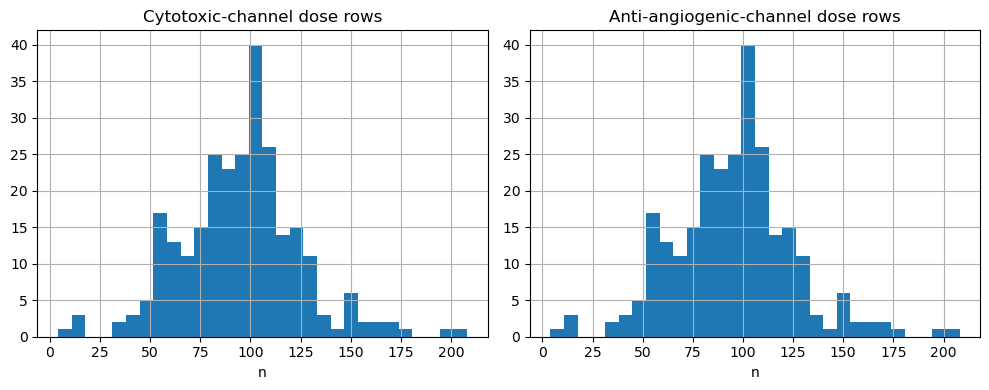

Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\plots\selected_stratum_dose_template_audit.png


In [8]:
# ---------------------------------------------------------------------
# Build real scan/dose templates for synthetic sampling
# ---------------------------------------------------------------------

template_rows = []

for tmpl in real_templates:
    sid = tmpl["study_id"]
    pid = tmpl["patient_id"]
    pk = tmpl["patient_key"]

    p_obs = get_patient_observations(sid, pid)
    clean = collapse_patient_observations(p_obs)

    if len(clean) < 2:
        continue

    first_scan_raw = float(clean["time_days"].iloc[0])
    last_time = float(clean["time_since_first_scan"].iloc[-1])

    schedule = schedule_from_patient_doses(
        get_patient_doses(sid, pid),
        first_scan_raw_day=first_scan_raw,
        stratum_signature=target_drug_signature + " " + target_arm,
        fallback_duration_days=last_time + 56.0,
    )

    template_rows.append({
        "patient_key": pk,
        "study_id": sid,
        "patient_id": pid,
        "times": tmpl["times"],
        "real_rel": tmpl["rel"],
        "baseline_sld_mm": tmpl["baseline_sld_mm"],
        "schedule": schedule,
        "n_cyt_doses": len(schedule.cyt_times),
        "n_anti_doses": len(schedule.anti_times),
    })

templates = template_rows

template_summary = pd.DataFrame([
    {
        "patient_key": t["patient_key"],
        "n_scans": len(t["times"]),
        "duration_days": float(t["times"][-1]),
        "baseline_sld_mm": t["baseline_sld_mm"],
        "n_cyt_doses": t["n_cyt_doses"],
        "n_anti_doses": t["n_anti_doses"],
    }
    for t in templates
])

template_summary_path = OUT_DIR / "selected_stratum_simulation_templates.csv"
template_summary.to_csv(template_summary_path, index=False)

print("Templates:", len(templates))
print("Saved:", template_summary_path)
display(template_summary.describe(include="all"))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(template_summary["n_cyt_doses"], bins=30)
axes[0].set_title("Cytotoxic-channel dose rows")
axes[0].set_xlabel("n")
axes[1].hist(template_summary["n_anti_doses"], bins=30)
axes[1].set_title("Anti-angiogenic-channel dose rows")
axes[1].set_xlabel("n")
fig.tight_layout()
path = PLOT_DIR / "selected_stratum_dose_template_audit.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", path)

## Candidate simulator A: Simeoni cytotoxic/transit-damage TGI

This is the baseline mechanistic family from the earlier notebooks. It assumes drug exposure causes proliferating tumor cells to enter a delayed damage/transit chain.

This model is appropriate as a benchmark, especially for FOLFOX-like chemotherapy components. It is not necessarily the best model for bevacizumab-like anti-angiogenic action.

In [9]:
# ---------------------------------------------------------------------
# Simulator A: Simeoni cytotoxic/transit-damage TGI
# ---------------------------------------------------------------------

SIMEONI_PARAM_NAMES = ["lam0", "lam1", "psi_g", "k_cyt", "k_tr", "v0"]

SIMEONI_PRIOR_LOW = np.array([
    np.log(0.003),     # lam0
    np.log(1000.0),    # lam1
    np.log(0.5),       # psi_g
    np.log(0.0002),    # k_cyt
    np.log(0.02),      # k_tr
    np.log(15.0),      # v0
])

SIMEONI_PRIOR_HIGH = np.array([
    np.log(0.08),
    np.log(30000.0),
    np.log(2.0),
    np.log(0.08),
    np.log(0.25),
    np.log(300.0),
])


def sample_simeoni_params(rng: np.random.Generator) -> dict:
    z = rng.uniform(SIMEONI_PRIOR_LOW, SIMEONI_PRIOR_HIGH)
    vals = np.exp(z)
    return dict(zip(SIMEONI_PARAM_NAMES, vals))


def simeoni_growth(x1: float, p: dict) -> float:
    x1 = max(float(x1), 1e-12)
    ratio = (p["lam0"] / p["lam1"]) * x1
    denom = (1.0 + ratio ** p["psi_g"]) ** (1.0 / p["psi_g"])
    return p["lam0"] * x1 / denom


def simeoni_rhs(t: float, x: np.ndarray, p: dict, schedule: MultiDoseSchedule) -> np.ndarray:
    x1, x2, x3, x4 = np.maximum(x, 0.0)

    c_cyt = schedule.concentration(t, "cyt")
    grow = simeoni_growth(x1, p)
    kill = p["k_cyt"] * c_cyt * x1

    return np.array([
        grow - kill,
        kill - p["k_tr"] * x2,
        p["k_tr"] * (x2 - x3),
        p["k_tr"] * (x3 - x4),
    ], dtype=float)


def simulate_simeoni(times: np.ndarray, schedule: MultiDoseSchedule, p: dict) -> np.ndarray:
    times = np.asarray(times, dtype=float)

    x0 = np.array([p["v0"], 0.0, 0.0, 0.0], dtype=float)

    sol = solve_ivp(
        fun=lambda t, x: simeoni_rhs(t, x, p, schedule),
        t_span=(float(times[0]), float(times[-1])),
        y0=x0,
        t_eval=times,
        method="LSODA",
        rtol=1e-6,
        atol=1e-8,
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    states = np.maximum(sol.y.T, 0.0)
    volume = states.sum(axis=1)
    rel = volume / max(float(volume[0]), 1e-8)
    return rel

## Candidate simulator B: anti-angiogenic carrying-capacity TGI

For bevacizumab-like treatment, a direct cell-kill model is probably too crude. A simple alternative is a tumor burden `V(t)` coupled to a vascular-support or carrying-capacity state `K(t)`.

The model is deliberately minimal:

$$
\frac{dV}{dt}
=
\rho V \left(1-\frac{V}{K}\right)
-
k_{\mathrm{cyt}} C_{\mathrm{cyt}}(t) V
$$

$$
\frac{dK}{dt}
=
k_K(K_0-K)
-
k_{\mathrm{anti}} C_{\mathrm{anti}}(t) K
$$

where:

- `V` is tumor burden;
- `K` is vascular support / carrying capacity;
- cytotoxic exposure reduces tumor burden directly;
- anti-angiogenic exposure reduces carrying capacity;
- `K` partially recovers toward baseline `K0`.

This is not a final pharmacometric model. It is a stable, interpretable candidate for synthetic SBI design.

In [10]:
# ---------------------------------------------------------------------
# Simulator B: anti-angiogenic carrying-capacity TGI
# ---------------------------------------------------------------------

ANGIO_PARAM_NAMES = [
    "rho",
    "k_cyt",
    "k_anti",
    "k_K_recovery",
    "K0_ratio",
    "v0",
]

ANGIO_PRIOR_LOW = np.array([
    np.log(0.002),      # rho
    np.log(0.0001),     # k_cyt
    np.log(0.0001),     # k_anti
    np.log(0.001),      # k_K_recovery
    np.log(1.10),       # K0_ratio
    np.log(15.0),       # v0
])

ANGIO_PRIOR_HIGH = np.array([
    np.log(0.06),
    np.log(0.05),
    np.log(0.08),
    np.log(0.06),
    np.log(8.0),
    np.log(300.0),
])


def sample_angio_params(rng: np.random.Generator) -> dict:
    z = rng.uniform(ANGIO_PRIOR_LOW, ANGIO_PRIOR_HIGH)
    vals = np.exp(z)
    return dict(zip(ANGIO_PARAM_NAMES, vals))


def angio_rhs(t: float, x: np.ndarray, p: dict, schedule: MultiDoseSchedule) -> np.ndarray:
    V, K = np.maximum(x, 1e-9)

    c_cyt = schedule.concentration(t, "cyt")
    c_anti = schedule.concentration(t, "anti")

    K = max(K, 1e-8)
    K0 = p["K0_ratio"] * p["v0"]

    growth = p["rho"] * V * (1.0 - V / K)
    cyt_kill = p["k_cyt"] * c_cyt * V

    dV = growth - cyt_kill
    dK = p["k_K_recovery"] * (K0 - K) - p["k_anti"] * c_anti * K

    return np.array([dV, dK], dtype=float)


def simulate_angio_carrying_capacity(times: np.ndarray, schedule: MultiDoseSchedule, p: dict) -> np.ndarray:
    times = np.asarray(times, dtype=float)

    v0 = float(p["v0"])
    K0 = float(p["K0_ratio"] * p["v0"])

    x0 = np.array([v0, K0], dtype=float)

    sol = solve_ivp(
        fun=lambda t, x: angio_rhs(t, x, p, schedule),
        t_span=(float(times[0]), float(times[-1])),
        y0=x0,
        t_eval=times,
        method="LSODA",
        rtol=1e-6,
        atol=1e-8,
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    states = np.maximum(sol.y.T, 1e-9)
    V = states[:, 0]
    rel = V / max(float(V[0]), 1e-8)
    return rel

## Observation model

For synthetic SBI, the latent trajectory must be turned into noisy observations.

We start with a data-driven residual model:

$$
\log y_{\text{obs}}(t_j) = \log y_{\text{latent}}(t_j) + \varepsilon_j
$$

where `epsilon_j` is sampled from the selected stratum's empirical rolling-origin residuals.

We also include optional:

- an isolated outlier;
- a persistent multiplicative observation shift after a random scan.

These are included because earlier diagnostics showed that some real trajectories contain isolated or persistent discontinuities.

Residual pool size: 772
Residual median: 0.0
Residual std: 0.23063418911697592
Residual q05/q95: [-0.27446691  0.36315111]


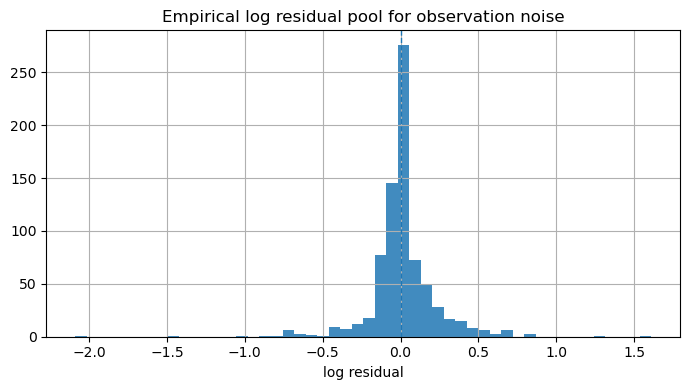

Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\plots\selected_stratum_empirical_residual_pool.png


In [11]:
# ---------------------------------------------------------------------
# Empirical residual pool for observation noise
# ---------------------------------------------------------------------

locf_resid = target_rolling[target_rolling["model"] == "LOCF"]["log_error"].dropna().to_numpy(dtype=float)

if len(locf_resid) < 20:
    locf_resid = target_rolling["log_error"].dropna().to_numpy(dtype=float)

if len(locf_resid) < 20:
    raise RuntimeError("Too few residuals to build empirical observation-noise model.")

print("Residual pool size:", len(locf_resid))
print("Residual median:", float(np.median(locf_resid)))
print("Residual std:", float(np.std(locf_resid, ddof=1)))
print("Residual q05/q95:", np.quantile(locf_resid, [0.05, 0.95]))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(locf_resid, bins=50, alpha=0.85)
ax.axvline(0.0, linestyle="--", linewidth=1)
ax.set_title("Empirical log residual pool for observation noise")
ax.set_xlabel("log residual")
fig.tight_layout()
path = PLOT_DIR / "selected_stratum_empirical_residual_pool.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", path)


def add_observation_noise(
    latent_rel: np.ndarray,
    rng: np.random.Generator,
    residual_pool: np.ndarray,
    p_outlier: float = 0.05,
    p_shift: float = 0.15,
    max_abs_log_shift: float = 0.40,
) -> tuple[np.ndarray, dict]:
    latent_rel = np.asarray(latent_rel, dtype=float)
    log_latent = np.log(np.maximum(latent_rel, 1e-8))

    eps = rng.choice(residual_pool, size=len(latent_rel), replace=True)
    log_obs = log_latent + eps

    meta = {
        "has_outlier": False,
        "outlier_idx": -1,
        "outlier_delta_log": 0.0,
        "has_shift": False,
        "shift_idx": -1,
        "shift_delta_log": 0.0,
    }

    if len(latent_rel) >= 4 and rng.random() < p_outlier:
        idx = int(rng.integers(1, len(latent_rel)))
        delta = float(rng.choice([-1.0, 1.0]) * rng.uniform(0.25, 0.75))
        log_obs[idx] += delta
        meta.update({
            "has_outlier": True,
            "outlier_idx": idx,
            "outlier_delta_log": delta,
        })

    if len(latent_rel) >= 6 and rng.random() < p_shift:
        idx = int(rng.integers(2, len(latent_rel) - 1))
        delta = float(rng.uniform(-max_abs_log_shift, max_abs_log_shift))
        log_obs[idx:] += delta
        meta.update({
            "has_shift": True,
            "shift_idx": idx,
            "shift_delta_log": delta,
        })

    obs = np.exp(log_obs)
    obs = obs / max(float(obs[0]), 1e-8)

    return obs, meta

## Prior-predictive simulation

This section samples real scan/dose templates and simulator parameters, then generates synthetic trajectories.

The output is used for two things:

1. Prior-predictive checking: do simulations look remotely like the real stratum?
2. Synthetic SBI training preparation: save padded arrays and parameter tables.

In [12]:
# ---------------------------------------------------------------------
# Prior-predictive synthetic cohort generation
# ---------------------------------------------------------------------

def is_sane_trajectory(rel: np.ndarray, max_rel: float = 20.0) -> bool:
    rel = np.asarray(rel, dtype=float)
    return (
        len(rel) >= 2
        and np.all(np.isfinite(rel))
        and np.all(rel > 0)
        and float(np.max(rel)) <= max_rel
        and float(np.min(rel)) >= 1e-5
    )


def sample_and_simulate_one(
    rng: np.random.Generator,
    simulator: str,
    residual_pool: np.ndarray,
    max_attempts: int = 50,
) -> dict:
    for attempt in range(max_attempts):
        template = templates[int(rng.integers(0, len(templates)))]
        times = np.asarray(template["times"], dtype=float)
        schedule = template["schedule"]

        try:
            if simulator == "simeoni":
                params = sample_simeoni_params(rng)
                latent = simulate_simeoni(times, schedule, params)
                param_names = SIMEONI_PARAM_NAMES
            elif simulator == "angio":
                params = sample_angio_params(rng)
                latent = simulate_angio_carrying_capacity(times, schedule, params)
                param_names = ANGIO_PARAM_NAMES
            else:
                raise ValueError(simulator)

            if not is_sane_trajectory(latent):
                continue

            obs, noise_meta = add_observation_noise(
                latent,
                rng=rng,
                residual_pool=residual_pool,
            )

            if not is_sane_trajectory(obs):
                continue

            summary_latent = trajectory_summary(times, latent)
            summary_obs = trajectory_summary(times, obs)

            return {
                "simulator": simulator,
                "template_patient_key": template["patient_key"],
                "times": times,
                "latent_rel": latent,
                "obs_rel": obs,
                "params": params,
                "param_names": param_names,
                "noise_meta": noise_meta,
                "summary_latent": summary_latent,
                "summary_obs": summary_obs,
                "attempt": attempt + 1,
            }

        except Exception:
            continue

    raise RuntimeError(f"Failed to generate sane {simulator} trajectory after {max_attempts} attempts.")


def generate_synthetic_cohort(n_per_simulator: int = 1000, seed: int = 2026) -> tuple[pd.DataFrame, list[dict]]:
    rng = np.random.default_rng(seed)

    rows = []
    sims = []
    sim_id = 0

    for simulator in ["simeoni", "angio"]:
        print(f"Generating {n_per_simulator} synthetic trajectories for {simulator}...")

        failures = 0

        while sum(1 for s in sims if s["simulator"] == simulator) < n_per_simulator:
            try:
                sim = sample_and_simulate_one(
                    rng,
                    simulator=simulator,
                    residual_pool=locf_resid,
                )
            except RuntimeError:
                failures += 1
                if failures > 100:
                    raise
                continue

            sim["sim_id"] = sim_id
            sims.append(sim)

            row = {
                "sim_id": sim_id,
                "simulator": simulator,
                "template_patient_key": sim["template_patient_key"],
                "n_scans": int(len(sim["times"])),
                "duration_days": float(sim["times"][-1]),
                "generation_attempt": int(sim["attempt"]),
                **{f"theta_{k}": float(v) for k, v in sim["params"].items()},
                **{f"noise_{k}": v for k, v in sim["noise_meta"].items()},
                **{f"latent_{k}": v for k, v in sim["summary_latent"].items()},
                **{f"obs_{k}": v for k, v in sim["summary_obs"].items()},
            }

            rows.append(row)
            sim_id += 1

    return pd.DataFrame(rows), sims


N_SYN_PER_SIMULATOR = 1000  # increase later for actual SBI training

synthetic_summary, synthetic_sims = generate_synthetic_cohort(
    n_per_simulator=N_SYN_PER_SIMULATOR,
    seed=202605,
)

synthetic_summary_path = SYNTH_OUT_DIR / "synthetic_prior_predictive_summary.csv"
synthetic_summary.to_csv(synthetic_summary_path, index=False)

print("Synthetic simulations:", len(synthetic_sims))
print("Saved:", synthetic_summary_path)
display(synthetic_summary.head())
display(synthetic_summary.groupby("simulator")["obs_response_class"].value_counts(normalize=True).to_frame("fraction"))

Generating 1000 synthetic trajectories for simeoni...
Generating 1000 synthetic trajectories for angio...
Synthetic simulations: 2000
Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\synthetic_data\synthetic_prior_predictive_summary.csv


,sim_id,simulator,template_patient_key,n_scans,duration_days,generation_attempt,theta_lam0,theta_lam1,theta_psi_g,theta_k_cyt,...,obs_median_gap_days,obs_max_gap_days,obs_min_rel_sld,obs_max_rel_sld,obs_final_rel_sld,obs_response_class,theta_rho,theta_k_anti,theta_k_K_recovery,theta_K0_ratio
0,0,simeoni,CEDIRANIB_HORIZONIII__25.0,6,359.0,4,0.003258,15571.802678,1.326617,0.000935,...,59.0,102.0,1.000000,3.017410,3.017410,progression_or_growth,NaN,NaN,NaN,NaN
1,1,simeoni,CEDIRANIB_HORIZONIII__18.0,7,424.0,1,0.008044,16988.524610,0.935538,0.005943,...,72.5,85.0,1.000000,4.261535,4.261535,progression_or_growth,NaN,NaN,NaN,NaN
2,2,simeoni,CEDIRANIB_HORIZONIII__409.0,7,343.0,1,0.009892,3075.557391,0.577654,0.025098,...,58.0,68.0,0.122702,1.000000,0.122702,response_or_shrinkage,NaN,NaN,NaN,NaN
3,3,simeoni,CEDIRANIB_HORIZONIII__656.0,7,455.0,1,0.008839,1397.451697,1.331294,0.042403,...,70.0,106.0,0.012216,1.000000,0.108530,response_then_regrowth,NaN,NaN,NaN,NaN
4,4,simeoni,CEDIRANIB_HORIZONIII__429.0,6,346.0,3,0.008545,22584.492070,1.797758,0.001085,...,66.0,94.0,1.000000,19.339841,19.339841,progression_or_growth,NaN,NaN,NaN,NaN


fraction
simulator obs_response_class              
angio     progression_or_growth      0.422
          response_or_shrinkage      0.297
          response_then_regrowth     0.246
          stable_like                0.035
simeoni   progression_or_growth      0.557
          response_or_shrinkage      0.339
          response_then_regrowth     0.099
          stable_like                0.005

In [13]:
# ---------------------------------------------------------------------
# Prior-predictive comparison: real vs synthetic summaries
# ---------------------------------------------------------------------

def summary_table_real_vs_synth(real_df: pd.DataFrame, synth_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for metric_name in ["min_rel_sld", "final_rel_sld", "max_rel_sld", "duration_days", "n_scans"]:
        if metric_name in real_df.columns:
            rows.append({
                "source": "real",
                "simulator": "real",
                "metric": metric_name,
                "median": float(real_df[metric_name].median()),
                "q10": float(real_df[metric_name].quantile(0.10)),
                "q90": float(real_df[metric_name].quantile(0.90)),
            })

    for simulator, g in synth_df.groupby("simulator"):
        for metric_name in ["min_rel_sld", "final_rel_sld", "max_rel_sld", "duration_days", "n_scans"]:
            col = f"obs_{metric_name}"
            if col in g.columns:
                rows.append({
                    "source": "synthetic",
                    "simulator": simulator,
                    "metric": metric_name,
                    "median": float(g[col].median()),
                    "q10": float(g[col].quantile(0.10)),
                    "q90": float(g[col].quantile(0.90)),
                })

    return pd.DataFrame(rows)


comparison_summary = summary_table_real_vs_synth(real_traj_summary, synthetic_summary)
comparison_summary_path = OUT_DIR / "real_vs_synthetic_prior_predictive_summary.csv"
comparison_summary.to_csv(comparison_summary_path, index=False)

display(comparison_summary)
print("Saved:", comparison_summary_path)

real_rc = real_traj_summary["response_class"].value_counts(normalize=True).rename("real").to_frame()

synth_rc = (
    synthetic_summary
    .pivot_table(
        index="obs_response_class",
        columns="simulator",
        values="sim_id",
        aggfunc="count",
        fill_value=0,
    )
)

synth_rc = synth_rc / synth_rc.sum(axis=0)
rc_compare = real_rc.join(synth_rc, how="outer").fillna(0.0)

display(rc_compare)

rc_path = OUT_DIR / "real_vs_synthetic_response_class_fractions.csv"
rc_compare.to_csv(rc_path)
print("Saved:", rc_path)

,source,simulator,metric,median,q10,q90
0,real,real,min_rel_sld,0.520626,0.255007,0.826875
1,real,real,final_rel_sld,0.628506,0.315230,1.000000
2,real,real,max_rel_sld,1.000000,1.000000,1.032105
3,real,real,duration_days,362.000000,326.000000,523.600000
4,real,real,n_scans,6.000000,6.000000,8.000000
5,synthetic,angio,min_rel_sld,0.615290,0.019466,1.000000
6,synthetic,angio,final_rel_sld,0.926589,0.026689,3.248226
7,synthetic,angio,max_rel_sld,1.236765,1.000000,4.000833
8,synthetic,angio,duration_days,360.000000,330.000000,523.000000
9,synthetic,angio,n_scans,6.000000,6.000000,8.100000


Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\real_vs_synthetic_prior_predictive_summary.csv


,real,angio,simeoni
progression_or_growth,0.018657,0.422,0.557
response_or_shrinkage,0.458955,0.297,0.339
response_then_regrowth,0.324627,0.246,0.099
stable_like,0.197761,0.035,0.005


Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\real_vs_synthetic_response_class_fractions.csv


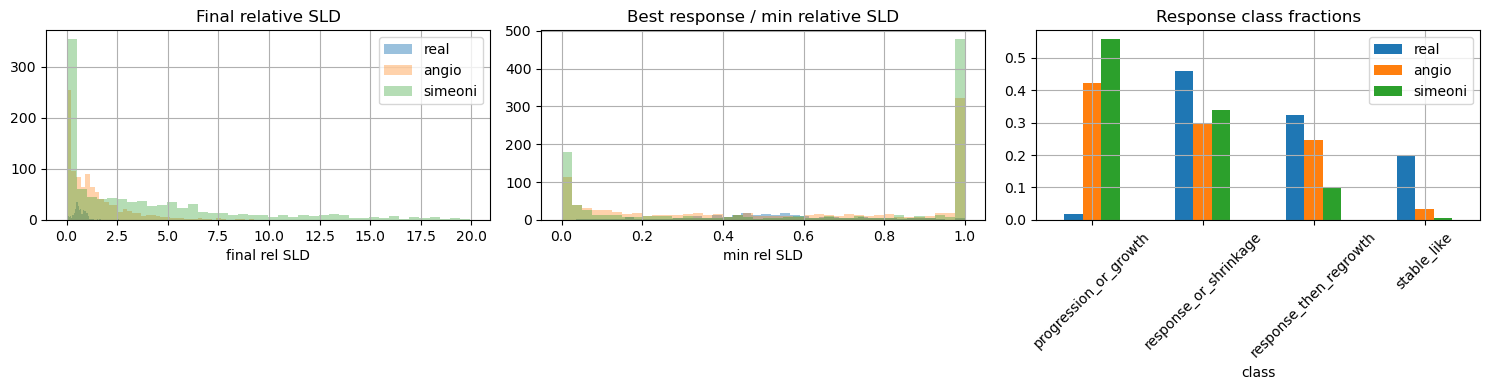

Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\plots\real_vs_synthetic_prior_predictive_histograms.png


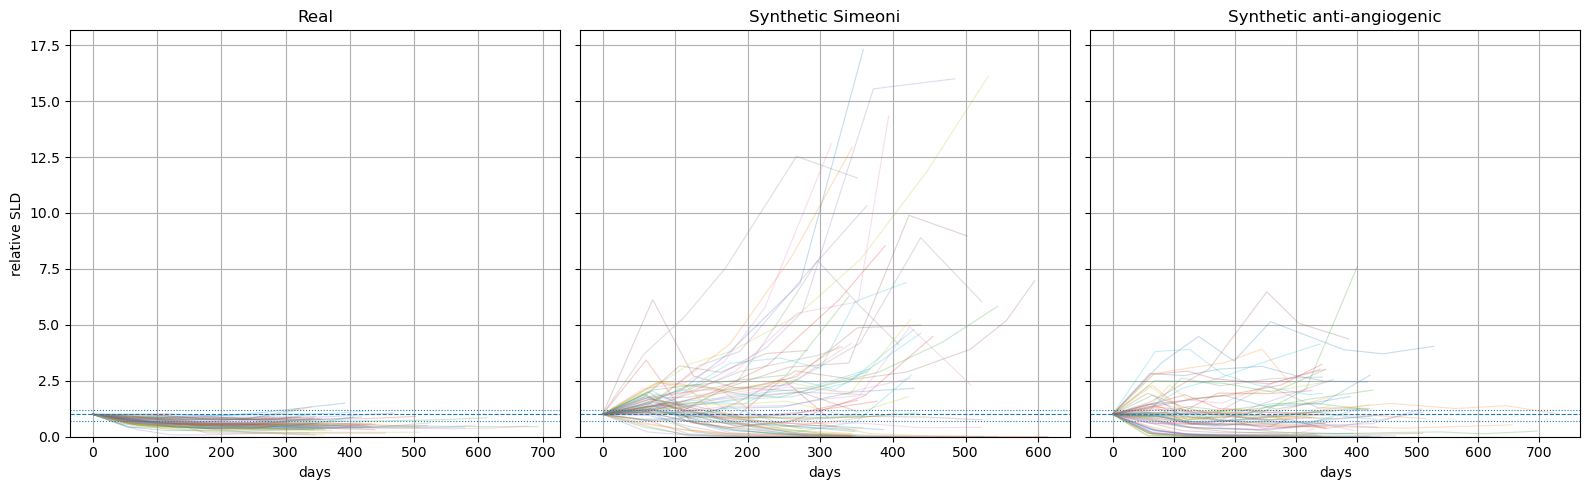

Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\plots\real_vs_synthetic_trajectory_overlays.png


In [14]:
# ---------------------------------------------------------------------
# Prior-predictive plots
# ---------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(real_traj_summary["final_rel_sld"].dropna(), bins=40, alpha=0.45, label="real")
for simulator, g in synthetic_summary.groupby("simulator"):
    axes[0].hist(g["obs_final_rel_sld"].dropna(), bins=40, alpha=0.35, label=simulator)
axes[0].set_title("Final relative SLD")
axes[0].set_xlabel("final rel SLD")
axes[0].legend()

axes[1].hist(real_traj_summary["min_rel_sld"].dropna(), bins=40, alpha=0.45, label="real")
for simulator, g in synthetic_summary.groupby("simulator"):
    axes[1].hist(g["obs_min_rel_sld"].dropna(), bins=40, alpha=0.35, label=simulator)
axes[1].set_title("Best response / min relative SLD")
axes[1].set_xlabel("min rel SLD")

rc_compare.plot(kind="bar", ax=axes[2])
axes[2].set_title("Response class fractions")
axes[2].set_xlabel("class")
axes[2].tick_params(axis="x", rotation=45)

fig.tight_layout()
path = PLOT_DIR / "real_vs_synthetic_prior_predictive_histograms.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", path)


rng = np.random.default_rng(456)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

idx = rng.choice(len(real_templates), size=min(70, len(real_templates)), replace=False)
for i in idx:
    axes[0].plot(real_templates[i]["times"], real_templates[i]["rel"], linewidth=0.8, alpha=0.25)
axes[0].set_title("Real")
axes[0].set_xlabel("days")
axes[0].set_ylabel("relative SLD")
axes[0].axhline(1.0, linestyle="--", linewidth=0.8)

s_sims = [s for s in synthetic_sims if s["simulator"] == "simeoni"]
idx = rng.choice(len(s_sims), size=min(70, len(s_sims)), replace=False)
for i in idx:
    axes[1].plot(s_sims[i]["times"], s_sims[i]["obs_rel"], linewidth=0.8, alpha=0.25)
axes[1].set_title("Synthetic Simeoni")
axes[1].set_xlabel("days")
axes[1].axhline(1.0, linestyle="--", linewidth=0.8)

a_sims = [s for s in synthetic_sims if s["simulator"] == "angio"]
idx = rng.choice(len(a_sims), size=min(70, len(a_sims)), replace=False)
for i in idx:
    axes[2].plot(a_sims[i]["times"], a_sims[i]["obs_rel"], linewidth=0.8, alpha=0.25)
axes[2].set_title("Synthetic anti-angiogenic")
axes[2].set_xlabel("days")
axes[2].axhline(1.0, linestyle="--", linewidth=0.8)

for ax in axes:
    ax.axhline(0.7, linestyle=":", linewidth=0.8)
    ax.axhline(1.2, linestyle=":", linewidth=0.8)
    ax.set_ylim(bottom=0)

fig.tight_layout()
path = PLOT_DIR / "real_vs_synthetic_trajectory_overlays.png"
fig.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", path)

## Save padded arrays for future SBI

The next notebook can train a neural posterior estimator. For that we need arrays with fixed shape.

We save:

- `x_obs`: `(N, T_max, 3)` containing time, log-relative SLD, mask;
- `theta`: parameter matrix;
- `theta_names`;
- `simulator_id`: `0 = simeoni`, `1 = angio`;
- `sim_id`;
- metadata CSV.

Because Simeoni and anti-angiogenic models have different parameter vectors, we save a union parameter table with `NaN` for parameters not belonging to a simulator.

In [15]:
# ---------------------------------------------------------------------
# Build padded SBI-ready arrays
# ---------------------------------------------------------------------

all_theta_names = sorted(
    set(f"theta_{k}" for k in SIMEONI_PARAM_NAMES)
    | set(f"theta_{k}" for k in ANGIO_PARAM_NAMES)
)

T_MAX = int(max(len(s["times"]) for s in synthetic_sims))
N = len(synthetic_sims)

x_obs = np.zeros((N, T_MAX, 3), dtype=np.float32)
theta = np.full((N, len(all_theta_names)), np.nan, dtype=np.float32)
simulator_id = np.zeros(N, dtype=np.int64)
sim_id_array = np.zeros(N, dtype=np.int64)

metadata_rows = []

TIME_SCALE = 365.0

for i, s in enumerate(synthetic_sims):
    times = np.asarray(s["times"], dtype=float)
    obs_rel = np.asarray(s["obs_rel"], dtype=float)

    L = len(times)

    x_obs[i, :L, 0] = (times / TIME_SCALE).astype(np.float32)
    x_obs[i, :L, 1] = np.log(np.maximum(obs_rel, 1e-8)).astype(np.float32)
    x_obs[i, :L, 2] = 1.0

    simulator_id[i] = 0 if s["simulator"] == "simeoni" else 1
    sim_id_array[i] = int(s["sim_id"])

    p = {f"theta_{k}": v for k, v in s["params"].items()}
    for j, name in enumerate(all_theta_names):
        if name in p:
            theta[i, j] = float(p[name])

    metadata_rows.append({
        "sim_id": int(s["sim_id"]),
        "simulator": s["simulator"],
        "simulator_id": int(simulator_id[i]),
        "template_patient_key": s["template_patient_key"],
        "n_scans": int(L),
        "duration_days": float(times[-1]),
        **{f"noise_{k}": v for k, v in s["noise_meta"].items()},
    })

metadata = pd.DataFrame(metadata_rows)

npz_path = SYNTH_OUT_DIR / "synthetic_sbi_ready_arrays.npz"
np.savez_compressed(
    npz_path,
    x_obs=x_obs,
    theta=theta,
    theta_names=np.array(all_theta_names, dtype=object),
    simulator_id=simulator_id,
    sim_id=sim_id_array,
    time_scale=np.array([TIME_SCALE], dtype=np.float32),
)

metadata_path = SYNTH_OUT_DIR / "synthetic_sbi_ready_metadata.csv"
metadata.to_csv(metadata_path, index=False)

theta_df = pd.DataFrame(theta, columns=all_theta_names)
theta_df.insert(0, "simulator_id", simulator_id)
theta_df.insert(0, "simulator", [s["simulator"] for s in synthetic_sims])
theta_df.insert(0, "sim_id", sim_id_array)
theta_path = SYNTH_OUT_DIR / "synthetic_theta_union_table.csv"
theta_df.to_csv(theta_path, index=False)

print("Saved:")
print(" ", npz_path)
print(" ", metadata_path)
print(" ", theta_path)

print("x_obs shape:", x_obs.shape)
print("theta shape:", theta.shape)
print("theta names:", all_theta_names)

display(metadata.head())
display(theta_df.head())

Saved:
  C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\synthetic_data\synthetic_sbi_ready_arrays.npz
  C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\synthetic_data\synthetic_sbi_ready_metadata.csv
  C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\synthetic_data\synthetic_theta_union_table.csv
x_obs shape: (2000, 14, 3)
theta shape: (2000, 10)
theta names: ['theta_K0_ratio', 'theta_k_K_recovery', 'theta_k_anti', 'theta_k_cyt', 'theta_k_tr', 'theta_lam0', 'theta_lam1', 'theta_psi_g', 'theta_rho', 'theta_v0']


,sim_id,simulator,simulator_id,template_patient_key,n_scans,duration_days,noise_has_outlier,noise_outlier_idx,noise_outlier_delta_log,noise_has_shift,noise_shift_idx,noise_shift_delta_log
0,0,simeoni,0,CEDIRANIB_HORIZONIII__25.0,6,359.0,False,-1,0.000000,True,4,-0.105985
1,1,simeoni,0,CEDIRANIB_HORIZONIII__18.0,7,424.0,False,-1,0.000000,False,-1,0.000000
2,2,simeoni,0,CEDIRANIB_HORIZONIII__409.0,7,343.0,True,1,-0.402307,False,-1,0.000000
3,3,simeoni,0,CEDIRANIB_HORIZONIII__656.0,7,455.0,False,-1,0.000000,False,-1,0.000000
4,4,simeoni,0,CEDIRANIB_HORIZONIII__429.0,6,346.0,False,-1,0.000000,False,-1,0.000000


,sim_id,simulator,simulator_id,theta_K0_ratio,theta_k_K_recovery,theta_k_anti,theta_k_cyt,theta_k_tr,theta_lam0,theta_lam1,theta_psi_g,theta_rho,theta_v0
0,0,simeoni,0,NaN,NaN,NaN,0.000935,0.097766,0.003258,15571.802734,1.326617,NaN,193.618652
1,1,simeoni,0,NaN,NaN,NaN,0.005943,0.097687,0.008044,16988.525391,0.935538,NaN,54.301449
2,2,simeoni,0,NaN,NaN,NaN,0.025098,0.173486,0.009892,3075.557373,0.577654,NaN,39.521866
3,3,simeoni,0,NaN,NaN,NaN,0.042403,0.087078,0.008839,1397.451660,1.331294,NaN,65.117851
4,4,simeoni,0,NaN,NaN,NaN,0.001085,0.081038,0.008545,22584.492188,1.797758,NaN,40.181511


In [16]:
# ---------------------------------------------------------------------
# Train/validation split for future SBI
# ---------------------------------------------------------------------

rng = np.random.default_rng(777)

indices = np.arange(N)
rng.shuffle(indices)

n_train = int(0.80 * N)
n_val = int(0.10 * N)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

split = {
    "train_idx": train_idx.tolist(),
    "val_idx": val_idx.tolist(),
    "test_idx": test_idx.tolist(),
}

split_path = SYNTH_OUT_DIR / "synthetic_train_val_test_split.json"
with open(split_path, "w") as f:
    json.dump(split, f, indent=2)

print("Split sizes:")
print(" train:", len(train_idx))
print(" val:  ", len(val_idx))
print(" test: ", len(test_idx))
print("Saved:", split_path)

Split sizes:
 train: 1600
 val:   200
 test:  200
Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\synthetic_data\synthetic_train_val_test_split.json


## Interpretation checklist

Inspect the prior-predictive plots before training SBI.

Good signs:

- synthetic final relative SLD overlaps the real distribution;
- synthetic response-class fractions are not wildly different;
- both simulators generate plausible trajectories;
- dose templates and scan schedules look realistic;
- observation noise produces variability comparable to the real stratum.

Bad signs:

- one simulator produces mostly explosive growth;
- one simulator produces almost only monotonic shrinkage;
- synthetic trajectories are far smoother than real trajectories;
- response/regrowth fraction is very different from the real stratum;
- dose-channel audit shows all rows assigned incorrectly.

If the prior predictive check looks bad, tune priors here before training NPE. Do not expect SBI to fix a bad simulator.

In [17]:
# ---------------------------------------------------------------------
# Save final notebook conclusion
# ---------------------------------------------------------------------

real_rc_frac = real_traj_summary["response_class"].value_counts(normalize=True).to_dict()
synthetic_rc_frac = (
    synthetic_summary
    .groupby("simulator")["obs_response_class"]
    .value_counts(normalize=True)
    .rename("fraction")
    .reset_index()
    .to_dict(orient="records")
)

conclusion = {
    "target_stratum": target.to_dict(),
    "n_real_patients": int(len(target_patients)),
    "n_templates": int(len(templates)),
    "n_synthetic_total": int(len(synthetic_sims)),
    "n_synthetic_per_simulator": synthetic_summary["simulator"].value_counts().to_dict(),
    "real_response_class_fraction": real_rc_frac,
    "synthetic_response_class_fraction": synthetic_rc_frac,
    "sbi_arrays": {
        "npz_path": str(npz_path),
        "x_obs_shape": list(x_obs.shape),
        "theta_shape": list(theta.shape),
        "theta_names": all_theta_names,
        "simulator_id_mapping": {"simeoni": 0, "angio": 1},
    },
    "recommended_next_notebook": "06_first_npe_synthetic_recovery_for_selected_stratum.ipynb",
    "next_step": (
        "Use the saved synthetic_sbi_ready_arrays.npz to train a first neural posterior estimator. "
        "Start with simulator_id-specific training or include simulator_id as a conditioning variable. "
        "Evaluate synthetic parameter recovery and posterior predictive calibration before applying to real patients."
    ),
}

conclusion_path = OUT_DIR / "selected_stratum_simulator_design_conclusion.json"
with open(conclusion_path, "w") as f:
    json.dump(conclusion, f, indent=2, default=str)

print(json.dumps(conclusion, indent=2, default=str)[:8000])
print("Saved:", conclusion_path)

{
  "target_stratum": {
    "study_id": "CEDIRANIB_HORIZONIII",
    "drug_signature": "FOLFOX + BEVACIZUMAB 5MG/KG",
    "arm": "FOLFOX + bevacizumab 5mg/kg",
    "model_family_hint": "anti_angiogenic_or_vascular_support_model",
    "n_patients": 268,
    "median_n_scans": 6.0,
    "median_duration_days": 362.0,
    "median_gap_days": 64.0,
    "dose_available_frac": 1.0,
    "response_then_regrowth_frac": 0.3246268656716418,
    "response_or_shrinkage_frac": 0.458955223880597,
    "progression_or_growth_frac": 0.0186567164179104,
    "n_predictions": 772,
    "baseline_rmse": 0.2973319777078372,
    "baseline_median_abs_log_error": 0.1104573223295606,
    "baseline_coverage_80": 0.8147668393782384,
    "baseline_coverage_90": 0.9313471502590672,
    "baseline_width_log_80": 0.5199307702521858,
    "sbi_readiness": "green",
    "readiness_reason": "sufficient_for_next_experiment"
  },
  "n_real_patients": 268,
  "n_templates": 268,
  "n_synthetic_total": 2000,
  "n_synthetic_per_simula

In [18]:
# ---------------------------------------------------------------------
# 05B config: multi-stratum prior predictive tuning
# ---------------------------------------------------------------------

RUN_MULTIPLE_STRATA = True

# Start small. Increase after the cell runs end-to-end.
N_STRATA_TO_RUN = 4
N_SYN_PER_STRATUM_PER_SIMULATOR = 600

# Generate a larger pool, then quota-select from it.
POOL_MULTIPLIER = 8

# If True, avoid treating cytotoxic and anti-angiogenic channels as separately
# identifiable when exposure schedules are nearly identical.
FIX_CYT_EFFECT_IN_ANGIO_IF_CONFOUNDED = True
FIXED_ANGIO_K_CYT = 0.006

# Target class smoothing prevents tiny real classes from becoming impossible.
MIN_CLASS_FRACTION_FOR_QUOTA = 0.03

# We will use green first, then yellow.
readiness_order = {"green": 0, "yellow": 1, "red": 2}

candidate_strata = starter_strata.copy()
candidate_strata["_readiness_order"] = candidate_strata["sbi_readiness"].map(readiness_order).fillna(9)

candidate_strata = candidate_strata.sort_values(
    ["_readiness_order", "n_patients", "n_predictions"],
    ascending=[True, False, False],
).drop(columns=["_readiness_order"])

if not RUN_MULTIPLE_STRATA:
    candidate_strata = candidate_strata[
        (candidate_strata["study_id"].astype(str) == target_study)
        & (candidate_strata["drug_signature"].astype(str) == target_drug_signature)
        & (candidate_strata["arm"].astype(str) == target_arm)
    ]

strata_to_run = candidate_strata.head(N_STRATA_TO_RUN).reset_index(drop=True)

print("Strata selected for 05B:")
display(
    strata_to_run[
        [
            "study_id",
            "drug_signature",
            "arm",
            "model_family_hint",
            "sbi_readiness",
            "n_patients",
            "n_predictions",
            "dose_available_frac",
            "response_or_shrinkage_frac",
            "response_then_regrowth_frac",
            "progression_or_growth_frac",
        ]
    ]
)

Strata selected for 05B:


,study_id,drug_signature,arm,model_family_hint,sbi_readiness,n_patients,n_predictions,dose_available_frac,response_or_shrinkage_frac,response_then_regrowth_frac,progression_or_growth_frac
0,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,anti_angiogenic_or_vascular_support_model,green,268,772,1.0,0.458955,0.324627,0.018657
1,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,cytotoxic_transit_damage_TGI,green,190,907,1.0,0.389474,0.457895,0.042105
2,EFC10262,5-FU+IRINOTECAN+LEUCOVORIN+PLACEBO,Placebo + FOLFIRI regimen,cytotoxic_transit_damage_TGI,green,190,850,1.0,0.184211,0.231579,0.184211
3,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFOX,cytotoxic_transit_damage_TGI,green,188,982,1.0,0.430851,0.452128,0.021277


In [19]:
# ---------------------------------------------------------------------
# Build reusable stratum bundles
# ---------------------------------------------------------------------

def build_stratum_bundle(stratum_row: pd.Series) -> dict:
    study_id = str(stratum_row["study_id"])
    drug_signature = str(stratum_row["drug_signature"])
    arm = str(stratum_row["arm"])

    patients = forecasting_cohort[
        (forecasting_cohort["study_id"].astype(str) == study_id)
        & (forecasting_cohort["drug_signature"].astype(str) == drug_signature)
        & (forecasting_cohort["arm"].astype(str) == arm)
    ].copy()

    if patients.empty:
        raise RuntimeError(f"No patients found for stratum: {study_id}, {drug_signature}, {arm}")

    keys = set(patients["patient_key"].astype(str))

    obs = all_obs[
        (all_obs["study_id"].astype(str) == study_id)
        & ((all_obs["study_id"].astype(str) + "__" + all_obs["patient_id"].astype(str)).isin(keys))
    ].copy()

    doses = all_doses[
        (all_doses["study_id"].astype(str) == study_id)
        & ((all_doses["study_id"].astype(str) + "__" + all_doses["patient_id"].astype(str)).isin(keys))
    ].copy()

    rolling = rolling_empirical[
        (rolling_empirical["study_id"].astype(str) == study_id)
        & (rolling_empirical["patient_key"].astype(str).isin(keys))
    ].copy()

    real_rows = []
    templates_local = []

    for _, prow in patients.iterrows():
        sid = str(prow["study_id"])
        pid = str(prow["patient_id"])
        pk = patient_key(sid, pid)

        p_obs = obs[
            (obs["study_id"].astype(str) == sid)
            & (obs["patient_id"].astype(str) == pid)
        ].copy()

        clean = collapse_patient_observations(p_obs)
        if len(clean) < 2:
            continue

        times = clean["time_since_first_scan"].to_numpy(dtype=float)
        rel = clean["rel_sld_renormalized"].to_numpy(dtype=float)

        first_scan_raw = float(clean["time_days"].iloc[0])
        last_time = float(times[-1])

        p_dose = doses[
            (doses["study_id"].astype(str) == sid)
            & (doses["patient_id"].astype(str) == pid)
        ].copy()

        schedule = schedule_from_patient_doses(
            p_dose,
            first_scan_raw_day=first_scan_raw,
            stratum_signature=drug_signature + " " + arm,
            fallback_duration_days=last_time + 56.0,
        )

        baseline_sld = (
            float(clean["baseline_sld_mm"].dropna().iloc[0])
            if clean["baseline_sld_mm"].notna().any()
            else np.nan
        )

        summ = trajectory_summary(times, rel)
        summ.update(
            {
                "study_id": sid,
                "patient_id": pid,
                "patient_key": pk,
                "baseline_sld_mm": baseline_sld,
                "n_cyt_doses": len(schedule.cyt_times),
                "n_anti_doses": len(schedule.anti_times),
            }
        )
        real_rows.append(summ)

        templates_local.append(
            {
                "study_id": sid,
                "patient_id": pid,
                "patient_key": pk,
                "times": times,
                "real_rel": rel,
                "baseline_sld_mm": baseline_sld,
                "schedule": schedule,
                "n_cyt_doses": len(schedule.cyt_times),
                "n_anti_doses": len(schedule.anti_times),
            }
        )

    real_summary = pd.DataFrame(real_rows)

    locf_residuals = rolling[rolling["model"] == "LOCF"]["log_error"].dropna().to_numpy(dtype=float)
    if len(locf_residuals) < 20:
        locf_residuals = rolling["log_error"].dropna().to_numpy(dtype=float)

    if len(locf_residuals) < 20:
        raise RuntimeError(f"Too few residuals for stratum {study_id}, {drug_signature}, {arm}")

    class_frac = real_summary["response_class"].value_counts(normalize=True).to_dict()

    # Smooth quotas slightly so very rare classes do not block generation.
    all_classes = [
        "response_or_shrinkage",
        "response_then_regrowth",
        "stable_like",
        "progression_or_growth",
    ]
    smoothed = {}
    for c in all_classes:
        smoothed[c] = max(float(class_frac.get(c, 0.0)), MIN_CLASS_FRACTION_FOR_QUOTA)

    total = sum(smoothed.values())
    smoothed = {k: v / total for k, v in smoothed.items()}

    return {
        "study_id": study_id,
        "drug_signature": drug_signature,
        "arm": arm,
        "model_family_hint": str(stratum_row.get("model_family_hint", "")),
        "patients": patients,
        "obs": obs,
        "doses": doses,
        "rolling": rolling,
        "templates": templates_local,
        "real_summary": real_summary,
        "locf_residuals": locf_residuals,
        "real_class_fraction": class_frac,
        "quota_class_fraction": smoothed,
        "stratum_row": stratum_row.to_dict(),
    }


stratum_bundles = []

for _, srow in strata_to_run.iterrows():
    bundle = build_stratum_bundle(srow)
    stratum_bundles.append(bundle)

    print("\n" + "=" * 100)
    print(bundle["study_id"], "|", bundle["drug_signature"], "|", bundle["arm"])
    print("patients:", len(bundle["patients"]))
    print("templates:", len(bundle["templates"]))
    print("real classes:", bundle["real_class_fraction"])
    print("quota classes:", bundle["quota_class_fraction"])
    print("LOCF residuals:", len(bundle["locf_residuals"]))

print("\nBuilt bundles:", len(stratum_bundles))


CEDIRANIB_HORIZONIII | FOLFOX + BEVACIZUMAB 5MG/KG | FOLFOX + bevacizumab 5mg/kg
patients: 268
templates: 268
real classes: {'response_or_shrinkage': 0.458955223880597, 'response_then_regrowth': 0.3246268656716418, 'stable_like': 0.19776119402985073, 'progression_or_growth': 0.018656716417910446}
quota classes: {'response_or_shrinkage': 0.4538075560802834, 'response_then_regrowth': 0.32098583234946876, 'stable_like': 0.195543093270366, 'progression_or_growth': 0.02966351829988194}
LOCF residuals: 772

DATASET_264 | 5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS+LEUCOVORIN+OXALIPLATIN | FOLFOX alone
patients: 190
templates: 190
real classes: {'response_then_regrowth': 0.45789473684210524, 'response_or_shrinkage': 0.3894736842105263, 'stable_like': 0.11052631578947368, 'progression_or_growth': 0.042105263157894736}
quota classes: {'response_or_shrinkage': 0.3894736842105263, 'response_then_regrowth': 0.45789473684210524, 'stable_like': 0.11052631578947368, 'progression_or_growth': 0.042

In [20]:
# ---------------------------------------------------------------------
# Dose-channel confounding audit
# ---------------------------------------------------------------------

def exposure_vector_at_times(schedule: MultiDoseSchedule, times: np.ndarray, channel: str) -> np.ndarray:
    return np.array([schedule.concentration(float(t), channel) for t in times], dtype=float)


def exposure_confounding_for_template(template: dict) -> dict:
    times = np.asarray(template["times"], dtype=float)
    sched = template["schedule"]

    c_cyt = exposure_vector_at_times(sched, times, "cyt")
    c_anti = exposure_vector_at_times(sched, times, "anti")

    cyt_nonzero = bool(np.any(c_cyt > 0))
    anti_nonzero = bool(np.any(c_anti > 0))

    if cyt_nonzero and anti_nonzero and np.std(c_cyt) > 1e-12 and np.std(c_anti) > 1e-12:
        corr = float(np.corrcoef(c_cyt, c_anti)[0, 1])
    else:
        corr = np.nan

    same_times = (
        len(sched.cyt_times) == len(sched.anti_times)
        and len(sched.cyt_times) > 0
        and np.allclose(sched.cyt_times, sched.anti_times)
    )

    return {
        "patient_key": template["patient_key"],
        "n_cyt_doses": int(len(sched.cyt_times)),
        "n_anti_doses": int(len(sched.anti_times)),
        "cyt_nonzero": cyt_nonzero,
        "anti_nonzero": anti_nonzero,
        "exposure_corr": corr,
        "same_dose_times": bool(same_times),
    }


confounding_rows = []

for bundle in stratum_bundles:
    for tmpl in bundle["templates"]:
        row = exposure_confounding_for_template(tmpl)
        row.update(
            {
                "study_id": bundle["study_id"],
                "drug_signature": bundle["drug_signature"],
                "arm": bundle["arm"],
            }
        )
        confounding_rows.append(row)

confounding_audit = pd.DataFrame(confounding_rows)

confounding_summary = (
    confounding_audit.groupby(["study_id", "drug_signature", "arm"])
    .agg(
        n_templates=("patient_key", "count"),
        frac_same_dose_times=("same_dose_times", "mean"),
        median_exposure_corr=("exposure_corr", "median"),
        frac_cyt_nonzero=("cyt_nonzero", "mean"),
        frac_anti_nonzero=("anti_nonzero", "mean"),
        median_n_cyt_doses=("n_cyt_doses", "median"),
        median_n_anti_doses=("n_anti_doses", "median"),
    )
    .reset_index()
)

confounding_audit_path = OUT_DIR / "05B_dose_channel_confounding_audit.csv"
confounding_summary_path = OUT_DIR / "05B_dose_channel_confounding_summary.csv"

confounding_audit.to_csv(confounding_audit_path, index=False)
confounding_summary.to_csv(confounding_summary_path, index=False)

display(confounding_summary)

print("Saved:")
print(" ", confounding_audit_path)
print(" ", confounding_summary_path)

,study_id,drug_signature,arm,n_templates,frac_same_dose_times,median_exposure_corr,frac_cyt_nonzero,frac_anti_nonzero,median_n_cyt_doses,median_n_anti_doses
0,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,268,1.0,0.873756,1.0,1.0,96.0,96.0
1,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,190,0.0,NaN,1.0,0.0,117.0,0.0
2,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFOX,188,0.0,NaN,1.0,0.0,125.5,0.0
3,EFC10262,5-FU+IRINOTECAN+LEUCOVORIN+PLACEBO,Placebo + FOLFIRI regimen,190,0.0,NaN,1.0,0.0,64.0,0.0


Saved:
  C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\05B_dose_channel_confounding_audit.csv
  C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\05B_dose_channel_confounding_summary.csv


In [21]:
# ---------------------------------------------------------------------
# Tuned prior samplers
# ---------------------------------------------------------------------
# These are still broad priors, but less growth-heavy than the first version.
# The objective is prior-predictive plausibility, not fitting real patients.

SIMEONI_TUNED_LOW = np.array([
    np.log(0.0015),    # lam0 lower growth
    np.log(1000.0),    # lam1
    np.log(0.5),       # psi_g
    np.log(0.001),     # k_cyt stronger minimum effect
    np.log(0.02),      # k_tr
])

SIMEONI_TUNED_HIGH = np.array([
    np.log(0.045),     # lam0
    np.log(30000.0),
    np.log(2.0),
    np.log(0.12),      # k_cyt
    np.log(0.25),
])

ANGIO_TUNED_LOW = np.array([
    np.log(0.001),     # rho
    np.log(0.0005),    # k_cyt
    np.log(0.002),     # k_anti stronger minimum anti effect
    np.log(0.0005),    # k_K_recovery
    np.log(1.05),      # K0_ratio
])

ANGIO_TUNED_HIGH = np.array([
    np.log(0.035),     # rho lower maximum growth
    np.log(0.035),     # k_cyt
    np.log(0.18),      # k_anti
    np.log(0.035),     # recovery
    np.log(5.0),       # K0_ratio
])


def sample_baseline_v0_from_bundle(bundle: dict, rng: np.random.Generator) -> float:
    vals = pd.to_numeric(bundle["real_summary"]["baseline_sld_mm"], errors="coerce").dropna().to_numpy(dtype=float)
    vals = vals[np.isfinite(vals) & (vals > 0)]

    if len(vals) == 0:
        return float(np.exp(rng.uniform(np.log(10.0), np.log(80.0))))

    return float(rng.choice(vals))


def sample_simeoni_params_tuned(bundle: dict, rng: np.random.Generator) -> dict:
    z = rng.uniform(SIMEONI_TUNED_LOW, SIMEONI_TUNED_HIGH)
    vals = np.exp(z)

    return {
        "lam0": float(vals[0]),
        "lam1": float(vals[1]),
        "psi_g": float(vals[2]),
        "k_cyt": float(vals[3]),
        "k_tr": float(vals[4]),
        "v0": sample_baseline_v0_from_bundle(bundle, rng),
    }


def stratum_is_exposure_confounded(bundle: dict) -> bool:
    mask = (
        (confounding_summary["study_id"].astype(str) == bundle["study_id"])
        & (confounding_summary["drug_signature"].astype(str) == bundle["drug_signature"])
        & (confounding_summary["arm"].astype(str) == bundle["arm"])
    )
    if not mask.any():
        return False

    row = confounding_summary[mask].iloc[0]

    frac_same = float(row["frac_same_dose_times"])
    corr = float(row["median_exposure_corr"]) if pd.notna(row["median_exposure_corr"]) else np.nan

    return bool(frac_same > 0.80 or (np.isfinite(corr) and corr > 0.98))


def sample_angio_params_tuned(bundle: dict, rng: np.random.Generator) -> dict:
    z = rng.uniform(ANGIO_TUNED_LOW, ANGIO_TUNED_HIGH)
    vals = np.exp(z)

    k_cyt = float(vals[1])

    if FIX_CYT_EFFECT_IN_ANGIO_IF_CONFOUNDED and stratum_is_exposure_confounded(bundle):
        k_cyt = FIXED_ANGIO_K_CYT

    return {
        "rho": float(vals[0]),
        "k_cyt": k_cyt,
        "k_anti": float(vals[2]),
        "k_K_recovery": float(vals[3]),
        "K0_ratio": float(vals[4]),
        "v0": sample_baseline_v0_from_bundle(bundle, rng),
    }


def simulate_with_tuned_prior(
    bundle: dict,
    rng: np.random.Generator,
    simulator: str,
    max_attempts: int = 80,
) -> dict:
    templates_local = bundle["templates"]
    residual_pool = bundle["locf_residuals"]

    for attempt in range(max_attempts):
        template = templates_local[int(rng.integers(0, len(templates_local)))]
        times = np.asarray(template["times"], dtype=float)
        schedule = template["schedule"]

        try:
            if simulator == "simeoni":
                params = sample_simeoni_params_tuned(bundle, rng)
                latent = simulate_simeoni(times, schedule, params)
                param_names = SIMEONI_PARAM_NAMES

            elif simulator == "angio":
                params = sample_angio_params_tuned(bundle, rng)
                latent = simulate_angio_carrying_capacity(times, schedule, params)
                param_names = ANGIO_PARAM_NAMES

            else:
                raise ValueError(simulator)

            if not is_sane_trajectory(latent, max_rel=20.0):
                continue

            obs, noise_meta = add_observation_noise(
                latent,
                rng=rng,
                residual_pool=residual_pool,
                p_outlier=0.04,
                p_shift=0.10,
                max_abs_log_shift=0.30,
            )

            if not is_sane_trajectory(obs, max_rel=20.0):
                continue

            return {
                "simulator": simulator,
                "study_id": bundle["study_id"],
                "drug_signature": bundle["drug_signature"],
                "arm": bundle["arm"],
                "template_patient_key": template["patient_key"],
                "times": times,
                "latent_rel": latent,
                "obs_rel": obs,
                "params": params,
                "param_names": param_names,
                "noise_meta": noise_meta,
                "summary_latent": trajectory_summary(times, latent),
                "summary_obs": trajectory_summary(times, obs),
                "attempt": attempt + 1,
                "dose_confounded": stratum_is_exposure_confounded(bundle),
            }

        except Exception:
            continue

    raise RuntimeError(f"Failed tuned simulation for {simulator}")

In [28]:
# ---------------------------------------------------------------------
# Quota-matched tuned prior predictive generation
# ---------------------------------------------------------------------
import copy
def quota_counts_from_fractions(fracs: dict, n: int) -> dict:
    classes = [
        "response_or_shrinkage",
        "response_then_regrowth",
        "stable_like",
        "progression_or_growth",
    ]

    raw = {c: float(fracs.get(c, 0.0)) * n for c in classes}
    counts = {c: int(np.floor(raw[c])) for c in classes}

    # distribute remainder by largest fractional parts
    remainder = n - sum(counts.values())
    order = sorted(classes, key=lambda c: raw[c] - np.floor(raw[c]), reverse=True)

    for c in order[:remainder]:
        counts[c] += 1

    return counts


def generate_pool_for_bundle(
    bundle: dict,
    simulator: str,
    n_pool: int,
    seed: int,
) -> tuple[pd.DataFrame, list[dict]]:
    rng = np.random.default_rng(seed)

    rows = []
    sims = []

    failures = 0
    attempts = 0

    while len(sims) < n_pool:
        attempts += 1
        if attempts > n_pool * 100:
            break

        try:
            sim = simulate_with_tuned_prior(bundle, rng, simulator=simulator)
        except RuntimeError:
            failures += 1
            continue

        local_id = len(sims)
        sim["local_pool_id"] = local_id
        sims.append(sim)

        row = {
            "local_pool_id": local_id,
            "simulator": simulator,
            "study_id": bundle["study_id"],
            "drug_signature": bundle["drug_signature"],
            "arm": bundle["arm"],
            "template_patient_key": sim["template_patient_key"],
            "n_scans": int(len(sim["times"])),
            "duration_days": float(sim["times"][-1]),
            "generation_attempt": int(sim["attempt"]),
            "dose_confounded": bool(sim["dose_confounded"]),
            **{f"theta_{k}": float(v) for k, v in sim["params"].items()},
            **{f"noise_{k}": v for k, v in sim["noise_meta"].items()},
            **{f"latent_{k}": v for k, v in sim["summary_latent"].items()},
            **{f"obs_{k}": v for k, v in sim["summary_obs"].items()},
        }

        rows.append(row)

    return pd.DataFrame(rows), sims


def select_quota_matched_sims(
    pool_df: pd.DataFrame,
    pool_sims: list[dict],
    target_fracs: dict,
    n_target: int,
    seed: int,
) -> tuple[pd.DataFrame, list[dict]]:
    rng = np.random.default_rng(seed)
    quotas = quota_counts_from_fractions(target_fracs, n_target)

    selected_ids = []

    for cls, q in quotas.items():
        candidates = pool_df[pool_df["obs_response_class"] == cls]["local_pool_id"].to_numpy(dtype=int)

        if len(candidates) == 0:
            continue

        replace = len(candidates) < q
        chosen = rng.choice(candidates, size=q, replace=replace)
        selected_ids.extend(chosen.tolist())

    # Fill remaining if some classes were impossible.
    if len(selected_ids) < n_target:
        remaining_needed = n_target - len(selected_ids)
        all_ids = pool_df["local_pool_id"].to_numpy(dtype=int)
        extra = rng.choice(all_ids, size=remaining_needed, replace=True)
        selected_ids.extend(extra.tolist())

    selected_ids = selected_ids[:n_target]

    selected_rows = pool_df.set_index("local_pool_id").loc[selected_ids].reset_index()
    selected_sims = [copy.deepcopy(pool_sims[int(i)]) for i in selected_ids]

    return selected_rows, selected_sims


all_tuned_rows = []
all_tuned_sims = []

global_sim_id = 0

for b_idx, bundle in enumerate(stratum_bundles):
    print("\n" + "=" * 110)
    print("Generating tuned prior predictive for:")
    print(bundle["study_id"], "|", bundle["drug_signature"], "|", bundle["arm"])

    for simulator in ["simeoni", "angio"]:
        n_pool = N_SYN_PER_STRATUM_PER_SIMULATOR * POOL_MULTIPLIER
        print(f"  simulator={simulator}, pool={n_pool}")

        pool_df, pool_sims = generate_pool_for_bundle(
            bundle=bundle,
            simulator=simulator,
            n_pool=n_pool,
            seed=202605 + 1000 * b_idx + (0 if simulator == "simeoni" else 500),
        )

        selected_df, selected_sims = select_quota_matched_sims(
            pool_df=pool_df,
            pool_sims=pool_sims,
            target_fracs=bundle["quota_class_fraction"],
            n_target=N_SYN_PER_STRATUM_PER_SIMULATOR,
            seed=9917 + 1000 * b_idx + (0 if simulator == "simeoni" else 500),
        )

        # Assign global IDs.
        for s in selected_sims:
            s["sim_id"] = global_sim_id
            global_sim_id += 1

        selected_df = selected_df.copy()
        selected_df["sim_id"] = [s["sim_id"] for s in selected_sims]
        selected_df["stratum_key"] = (
            selected_df["study_id"].astype(str)
            + "||" + selected_df["drug_signature"].astype(str)
            + "||" + selected_df["arm"].astype(str)
        )

        all_tuned_rows.append(selected_df)
        all_tuned_sims.extend(selected_sims)

        print("  selected response fractions:")
        display(selected_df["obs_response_class"].value_counts(normalize=True).to_frame("fraction"))

tuned_synthetic_summary = pd.concat(all_tuned_rows, ignore_index=True)

tuned_summary_path = SYNTH_OUT_DIR / "05B_tuned_multistratum_synthetic_summary.csv"
tuned_synthetic_summary.to_csv(tuned_summary_path, index=False)

print("\nTuned synthetic simulations:", len(all_tuned_sims))
print("Saved:", tuned_summary_path)

display(tuned_synthetic_summary.head())
display(
    tuned_synthetic_summary
    .groupby(["study_id", "drug_signature", "arm", "simulator"])["obs_response_class"]
    .value_counts(normalize=True)
    .rename("fraction")
    .reset_index()
    .head(80)
)


Generating tuned prior predictive for:
CEDIRANIB_HORIZONIII | FOLFOX + BEVACIZUMAB 5MG/KG | FOLFOX + bevacizumab 5mg/kg
  simulator=simeoni, pool=4800
  selected response fractions:


,fraction
obs_response_class,
response_or_shrinkage,0.453333
response_then_regrowth,0.321667
stable_like,0.195000
progression_or_growth,0.030000


  simulator=angio, pool=4800
  selected response fractions:


,fraction
obs_response_class,
response_or_shrinkage,0.453333
response_then_regrowth,0.321667
stable_like,0.195000
progression_or_growth,0.030000



Generating tuned prior predictive for:
DATASET_264 | 5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS+LEUCOVORIN+OXALIPLATIN | FOLFOX alone
  simulator=simeoni, pool=4800
  selected response fractions:


...

  simulator=angio, pool=4800
  selected response fractions:


,fraction
obs_response_class,
response_then_regrowth,0.448333
response_or_shrinkage,0.426667
stable_like,0.095000
progression_or_growth,0.030000



Tuned synthetic simulations: 4800
Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\synthetic_data\05B_tuned_multistratum_synthetic_summary.csv


,local_pool_id,simulator,study_id,drug_signature,arm,template_patient_key,n_scans,duration_days,generation_attempt,dose_confounded,...,obs_min_rel_sld,obs_max_rel_sld,obs_final_rel_sld,obs_response_class,sim_id,stratum_key,theta_rho,theta_k_anti,theta_k_K_recovery,theta_K0_ratio
0,4620,simeoni,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,CEDIRANIB_HORIZONIII__526.0,7,429.0,1,True,...,0.052016,1.000000,0.052016,response_or_shrinkage,0,CEDIRANIB_HORIZONIII||FOLFOX + BEVACIZUMAB 5MG...,NaN,NaN,NaN,NaN
1,723,simeoni,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,CEDIRANIB_HORIZONIII__670.0,7,457.0,1,True,...,0.225560,1.119527,0.230957,response_or_shrinkage,1,CEDIRANIB_HORIZONIII||FOLFOX + BEVACIZUMAB 5MG...,NaN,NaN,NaN,NaN
2,3135,simeoni,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,CEDIRANIB_HORIZONIII__669.0,6,353.0,1,True,...,0.043865,2.001097,0.043865,response_or_shrinkage,2,CEDIRANIB_HORIZONIII||FOLFOX + BEVACIZUMAB 5MG...,NaN,NaN,NaN,NaN
3,474,simeoni,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,CEDIRANIB_HORIZONIII__332.0,7,422.0,7,True,...,0.000093,1.000000,0.000093,response_or_shrinkage,3,CEDIRANIB_HORIZONIII||FOLFOX + BEVACIZUMAB 5MG...,NaN,NaN,NaN,NaN
4,1,simeoni,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,CEDIRANIB_HORIZONIII__546.0,10,692.0,3,True,...,0.000200,1.180258,0.000200,response_or_shrinkage,4,CEDIRANIB_HORIZONIII||FOLFOX + BEVACIZUMAB 5MG...,NaN,NaN,NaN,NaN


,study_id,drug_signature,arm,simulator,obs_response_class,fraction
0,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,angio,response_or_shrinkage,0.453333
1,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,angio,response_then_regrowth,0.321667
2,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,angio,stable_like,0.195000
3,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,angio,progression_or_growth,0.030000
4,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,simeoni,response_or_shrinkage,0.453333
5,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,simeoni,response_then_regrowth,0.321667
6,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,simeoni,stable_like,0.195000
7,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,simeoni,progression_or_growth,0.030000
8,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,angio,response_then_regrowth,0.458333
9,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,angio,response_or_shrinkage,0.390000


,study_id,drug_signature,arm,source,simulator,count,median_abs_log_error,rmse,q05,q50,q95
0,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,real,real,772,0.063693,0.230818,-0.274467,0.000000,0.363151
1,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,synthetic,angio,1691,0.223665,0.419880,-0.696434,-0.046953,0.617412
2,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,synthetic,simeoni,1637,0.452592,1.083371,-2.371176,-0.215770,0.771932
3,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,real,real,907,0.072321,0.284677,-0.322911,0.000000,0.463171
4,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,synthetic,angio,2868,0.249809,0.599376,-1.119205,-0.020266,0.684833
5,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,synthetic,simeoni,2687,0.404456,0.896283,-1.772340,-0.112561,0.955972
6,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFOX,real,real,982,0.080043,0.312369,-0.363471,0.000000,0.434849
7,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFOX,synthetic,angio,2986,0.274612,0.597929,-1.197848,-0.072293,0.737905
8,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFOX,synthetic,simeoni,2798,0.408267,0.878428,-1.779158,-0.155690,0.842795
9,EFC10262,5-FU+IRINOTECAN+LEUCOVORIN+PLACEBO,Placebo + FOLFIRI regimen,real,real,850,0.042560,0.383769,-0.191407,0.000000,0.337644


Saved:
  C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\synthetic_data\05B_real_vs_synthetic_locf_residuals_long.csv
  C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\synthetic_data\05B_real_vs_synthetic_locf_residual_summary.csv


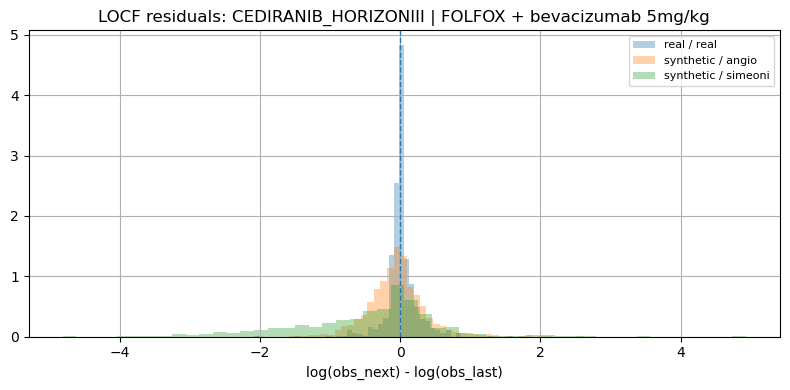

Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\plots\05B_locf_residual_compare_CEDIRANIB_HORIZONIII.png


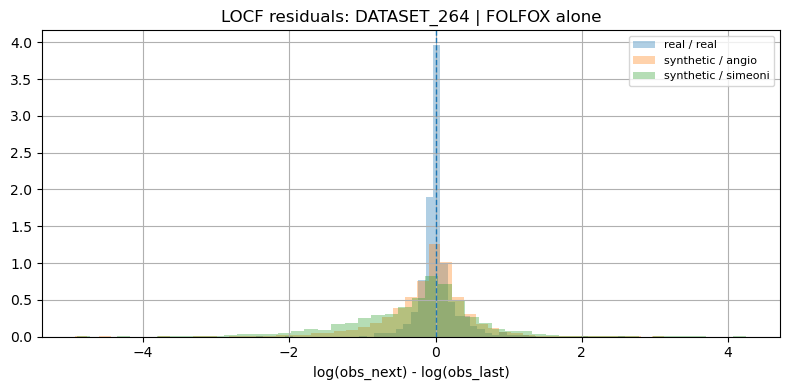

Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\plots\05B_locf_residual_compare_DATASET_264.png


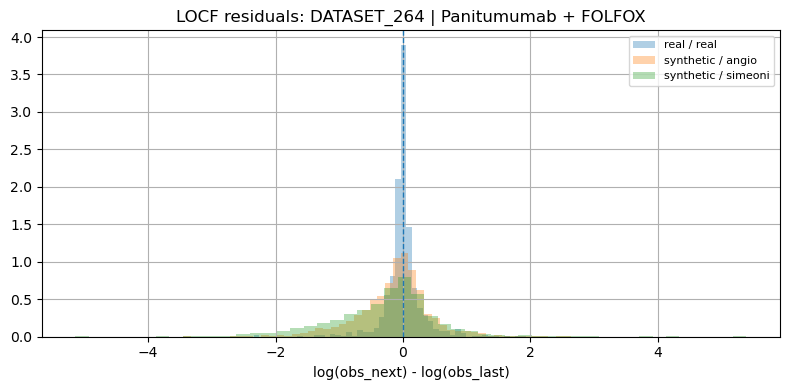

Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\plots\05B_locf_residual_compare_DATASET_264.png


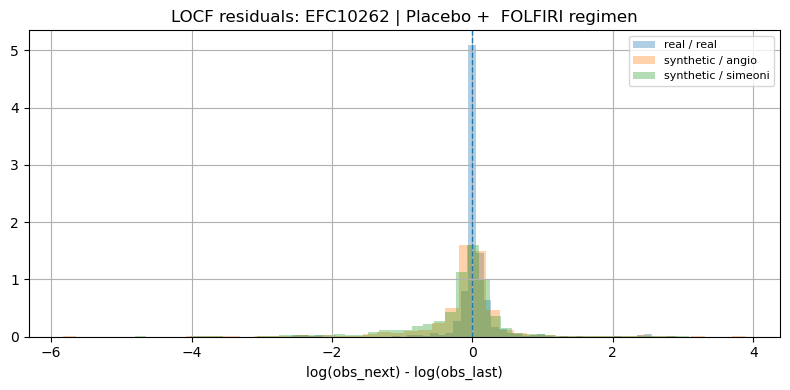

Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\plots\05B_locf_residual_compare_EFC10262.png


In [29]:
# ---------------------------------------------------------------------
# Real-vs-synthetic LOCF residual diagnostics
# ---------------------------------------------------------------------

MIN_TRAIN_SCANS = 4
def locf_residuals_for_trajectory(times: np.ndarray, rel: np.ndarray, min_train: int = 4) -> np.ndarray:
    rel = np.asarray(rel, dtype=float)
    if len(rel) <= min_train:
        return np.array([], dtype=float)

    errs = []
    for j in range(min_train, len(rel)):
        pred = max(float(rel[j - 1]), 1e-8)
        obs = max(float(rel[j]), 1e-8)
        errs.append(float(np.log(obs) - np.log(pred)))

    return np.asarray(errs, dtype=float)


locf_rows = []

# Real residuals per stratum.
for bundle in stratum_bundles:
    for tmpl in bundle["templates"]:
        errs = locf_residuals_for_trajectory(tmpl["times"], tmpl["real_rel"], min_train=MIN_TRAIN_SCANS)
        for e in errs:
            locf_rows.append(
                {
                    "source": "real",
                    "simulator": "real",
                    "study_id": bundle["study_id"],
                    "drug_signature": bundle["drug_signature"],
                    "arm": bundle["arm"],
                    "log_error": float(e),
                    "abs_log_error": abs(float(e)),
                    "squared_log_error": float(e) ** 2,
                }
            )

# Synthetic residuals.
for sim in all_tuned_sims:
    errs = locf_residuals_for_trajectory(sim["times"], sim["obs_rel"], min_train=MIN_TRAIN_SCANS)
    for e in errs:
        locf_rows.append(
            {
                "source": "synthetic",
                "simulator": sim["simulator"],
                "study_id": sim["study_id"],
                "drug_signature": sim["drug_signature"],
                "arm": sim["arm"],
                "log_error": float(e),
                "abs_log_error": abs(float(e)),
                "squared_log_error": float(e) ** 2,
            }
        )

locf_compare = pd.DataFrame(locf_rows)

locf_summary = (
    locf_compare
    .groupby(["study_id", "drug_signature", "arm", "source", "simulator"])
    .agg(
        count=("log_error", "count"),
        median_abs_log_error=("abs_log_error", "median"),
        rmse=("squared_log_error", lambda x: float(np.sqrt(np.mean(x)))),
        q05=("log_error", lambda x: float(np.quantile(x, 0.05))),
        q50=("log_error", lambda x: float(np.quantile(x, 0.50))),
        q95=("log_error", lambda x: float(np.quantile(x, 0.95))),
    )
    .reset_index()
)

locf_compare_path = SYNTH_OUT_DIR / "05B_real_vs_synthetic_locf_residuals_long.csv"
locf_summary_path = SYNTH_OUT_DIR / "05B_real_vs_synthetic_locf_residual_summary.csv"

locf_compare.to_csv(locf_compare_path, index=False)
locf_summary.to_csv(locf_summary_path, index=False)

display(locf_summary.head(80))

print("Saved:")
print(" ", locf_compare_path)
print(" ", locf_summary_path)

# Plot for first few strata.
plot_strata = (
    locf_summary[["study_id", "drug_signature", "arm"]]
    .drop_duplicates()
    .head(min(4, len(stratum_bundles)))
)

for _, row in plot_strata.iterrows():
    mask = (
        (locf_compare["study_id"].astype(str) == str(row["study_id"]))
        & (locf_compare["drug_signature"].astype(str) == str(row["drug_signature"]))
        & (locf_compare["arm"].astype(str) == str(row["arm"]))
    )
    g = locf_compare[mask]

    fig, ax = plt.subplots(figsize=(8, 4))
    for label, gg in g.groupby(["source", "simulator"]):
        name = " / ".join(label)
        ax.hist(gg["log_error"], bins=50, alpha=0.35, density=True, label=name)

    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_title(f"LOCF residuals: {row['study_id']} | {row['arm']}")
    ax.set_xlabel("log(obs_next) - log(obs_last)")
    ax.legend(fontsize=8)
    fig.tight_layout()

    safe_name = str(row["study_id"]).replace(" ", "_")[:40]
    path = PLOT_DIR / f"05B_locf_residual_compare_{safe_name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", path)
    

In [30]:
# ---------------------------------------------------------------------
# Real-vs-tuned synthetic response-class and summary comparison
# ---------------------------------------------------------------------

comparison_rows = []

for bundle in stratum_bundles:
    real_df = bundle["real_summary"].copy()

    comparison_rows.append(
        {
            "study_id": bundle["study_id"],
            "drug_signature": bundle["drug_signature"],
            "arm": bundle["arm"],
            "source": "real",
            "simulator": "real",
            "n": len(real_df),
            "median_final_rel_sld": float(real_df["final_rel_sld"].median()),
            "median_min_rel_sld": float(real_df["min_rel_sld"].median()),
            "median_max_rel_sld": float(real_df["max_rel_sld"].median()),
            "frac_progression_or_growth": float((real_df["response_class"] == "progression_or_growth").mean()),
            "frac_response_or_shrinkage": float((real_df["response_class"] == "response_or_shrinkage").mean()),
            "frac_response_then_regrowth": float((real_df["response_class"] == "response_then_regrowth").mean()),
            "frac_stable_like": float((real_df["response_class"] == "stable_like").mean()),
        }
    )

for (study, drug, arm, simulator), g in tuned_synthetic_summary.groupby(["study_id", "drug_signature", "arm", "simulator"]):
    comparison_rows.append(
        {
            "study_id": study,
            "drug_signature": drug,
            "arm": arm,
            "source": "synthetic",
            "simulator": simulator,
            "n": len(g),
            "median_final_rel_sld": float(g["obs_final_rel_sld"].median()),
            "median_min_rel_sld": float(g["obs_min_rel_sld"].median()),
            "median_max_rel_sld": float(g["obs_max_rel_sld"].median()),
            "frac_progression_or_growth": float((g["obs_response_class"] == "progression_or_growth").mean()),
            "frac_response_or_shrinkage": float((g["obs_response_class"] == "response_or_shrinkage").mean()),
            "frac_response_then_regrowth": float((g["obs_response_class"] == "response_then_regrowth").mean()),
            "frac_stable_like": float((g["obs_response_class"] == "stable_like").mean()),
        }
    )

tuned_comparison = pd.DataFrame(comparison_rows)

tuned_comparison_path = SYNTH_OUT_DIR / "05B_real_vs_tuned_synthetic_summary.csv"
tuned_comparison.to_csv(tuned_comparison_path, index=False)

display(tuned_comparison.head(80))
print("Saved:", tuned_comparison_path)

,study_id,drug_signature,arm,source,simulator,n,median_final_rel_sld,median_min_rel_sld,median_max_rel_sld,frac_progression_or_growth,frac_response_or_shrinkage,frac_response_then_regrowth,frac_stable_like
0,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,real,real,268,0.628506,0.520626,1.000000,0.018657,0.458955,0.324627,0.197761
1,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,real,real,190,0.618803,0.403973,1.000000,0.042105,0.389474,0.457895,0.110526
2,EFC10262,5-FU+IRINOTECAN+LEUCOVORIN+PLACEBO,Placebo + FOLFIRI regimen,real,real,190,0.947991,0.743277,1.000000,0.184211,0.184211,0.231579,0.400000
3,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFOX,real,real,188,0.566432,0.353407,1.000000,0.021277,0.430851,0.452128,0.095745
4,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,synthetic,angio,600,0.263330,0.188067,1.000000,0.030000,0.453333,0.321667,0.195000
5,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,synthetic,simeoni,600,0.268902,0.172862,1.064548,0.030000,0.453333,0.321667,0.195000
6,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,synthetic,angio,600,0.490127,0.284766,1.000000,0.041667,0.390000,0.458333,0.110000
7,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,synthetic,simeoni,600,0.272721,0.121725,1.072481,0.041667,0.390000,0.458333,0.110000
8,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFOX,synthetic,angio,600,0.388431,0.235051,1.000000,0.030000,0.426667,0.448333,0.095000
9,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFOX,synthetic,simeoni,600,0.201138,0.096862,1.070859,0.030000,0.426667,0.448333,0.095000


Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\synthetic_data\05B_real_vs_tuned_synthetic_summary.csv


In [31]:
# ---------------------------------------------------------------------
# Grouped train/val/test split by template patient
# ---------------------------------------------------------------------

def grouped_split_by_template(
    sims: list[dict],
    train_frac: float = 0.80,
    val_frac: float = 0.10,
    seed: int = 777,
) -> dict:
    rng = np.random.default_rng(seed)

    # Split within each stratum and simulator so all groups are represented.
    rows = []
    for i, s in enumerate(sims):
        rows.append(
            {
                "idx": i,
                "sim_id": int(s["sim_id"]),
                "study_id": s["study_id"],
                "drug_signature": s["drug_signature"],
                "arm": s["arm"],
                "simulator": s["simulator"],
                "template_patient_key": s["template_patient_key"],
            }
        )

    df = pd.DataFrame(rows)

    train_ids = []
    val_ids = []
    test_ids = []

    for keys, g in df.groupby(["study_id", "drug_signature", "arm", "simulator"]):
        templates_unique = g["template_patient_key"].drop_duplicates().to_numpy()
        rng.shuffle(templates_unique)

        n = len(templates_unique)
        n_train = max(1, int(train_frac * n))
        n_val = max(1, int(val_frac * n)) if n >= 10 else max(0, int(val_frac * n))

        train_templates = set(templates_unique[:n_train])
        val_templates = set(templates_unique[n_train:n_train + n_val])
        test_templates = set(templates_unique[n_train + n_val:])

        if len(test_templates) == 0 and len(val_templates) > 1:
            moved = list(val_templates)[-1]
            val_templates.remove(moved)
            test_templates.add(moved)

        train_ids.extend(g[g["template_patient_key"].isin(train_templates)]["sim_id"].tolist())
        val_ids.extend(g[g["template_patient_key"].isin(val_templates)]["sim_id"].tolist())
        test_ids.extend(g[g["template_patient_key"].isin(test_templates)]["sim_id"].tolist())

    return {
        "train_sim_id": sorted(map(int, train_ids)),
        "val_sim_id": sorted(map(int, val_ids)),
        "test_sim_id": sorted(map(int, test_ids)),
    }


grouped_split = grouped_split_by_template(all_tuned_sims, seed=202606)

split_path = SYNTH_OUT_DIR / "05B_grouped_template_train_val_test_split.json"
with open(split_path, "w") as f:
    json.dump(grouped_split, f, indent=2)

print("Grouped split sizes:")
print(" train:", len(grouped_split["train_sim_id"]))
print(" val:  ", len(grouped_split["val_sim_id"]))
print(" test: ", len(grouped_split["test_sim_id"]))
print("Saved:", split_path)

Grouped split sizes:
 train: 3841
 val:   474
 test:  485
Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\synthetic_data\05B_grouped_template_train_val_test_split.json


In [32]:
# ---------------------------------------------------------------------
# Export per-simulator, no-NaN SBI arrays
# ---------------------------------------------------------------------

def build_sbi_arrays_for_simulator(
    sims: list[dict],
    simulator: str,
    theta_names: list[str],
    out_prefix: str,
    include_covariates: bool = True,
) -> dict:
    selected = [s for s in sims if s["simulator"] == simulator]

    if not selected:
        raise RuntimeError(f"No simulations for simulator={simulator}")

    T_max = int(max(len(s["times"]) for s in selected))
    N = len(selected)

    # x_obs columns:
    #   0 time_scaled
    #   1 log_rel_sld
    #   2 mask
    x_obs = np.zeros((N, T_max, 3), dtype=np.float32)
    theta = np.zeros((N, len(theta_names)), dtype=np.float32)
    sim_id = np.zeros(N, dtype=np.int64)

    # x_cov:
    #   log_baseline_sld_mm
    #   duration_days_scaled
    #   n_scans_scaled
    #   dose_confounded flag
    x_cov = np.zeros((N, 4), dtype=np.float32)

    metadata_rows = []

    for i, s in enumerate(selected):
        times = np.asarray(s["times"], dtype=float)
        obs_rel = np.asarray(s["obs_rel"], dtype=float)

        L = len(times)

        x_obs[i, :L, 0] = (times / 365.0).astype(np.float32)
        x_obs[i, :L, 1] = np.log(np.maximum(obs_rel, 1e-8)).astype(np.float32)
        x_obs[i, :L, 2] = 1.0

        for j, name in enumerate(theta_names):
            theta[i, j] = float(s["params"][name])

        sim_id[i] = int(s["sim_id"])

        # recover baseline from template if possible
        baseline = np.nan
        for b in stratum_bundles:
            for tmpl in b["templates"]:
                if tmpl["patient_key"] == s["template_patient_key"]:
                    baseline = tmpl.get("baseline_sld_mm", np.nan)
                    break

        if not np.isfinite(baseline) or baseline <= 0:
            baseline = float(s["params"].get("v0", 1.0))

        x_cov[i, 0] = np.log(max(float(baseline), 1e-8))
        x_cov[i, 1] = float(times[-1] / 365.0)
        x_cov[i, 2] = float(L / 20.0)
        x_cov[i, 3] = float(bool(s.get("dose_confounded", False)))

        metadata_rows.append(
            {
                "row_idx": i,
                "sim_id": int(s["sim_id"]),
                "simulator": simulator,
                "study_id": s["study_id"],
                "drug_signature": s["drug_signature"],
                "arm": s["arm"],
                "template_patient_key": s["template_patient_key"],
                "n_scans": int(L),
                "duration_days": float(times[-1]),
                "dose_confounded": bool(s.get("dose_confounded", False)),
                **{f"noise_{k}": v for k, v in s["noise_meta"].items()},
            }
        )

    metadata = pd.DataFrame(metadata_rows)

    npz_path = SYNTH_OUT_DIR / f"{out_prefix}_{simulator}_sbi_arrays_no_nan.npz"
    meta_path = SYNTH_OUT_DIR / f"{out_prefix}_{simulator}_metadata.csv"
    theta_path = SYNTH_OUT_DIR / f"{out_prefix}_{simulator}_theta.csv"

    np.savez_compressed(
        npz_path,
        x_obs=x_obs,
        x_cov=x_cov,
        theta=theta,
        theta_names=np.array(theta_names, dtype=object),
        sim_id=sim_id,
        time_scale=np.array([365.0], dtype=np.float32),
        cov_names=np.array(
            ["log_baseline_sld_mm", "duration_years", "n_scans_over_20", "dose_confounded"],
            dtype=object,
        ),
    )

    metadata.to_csv(meta_path, index=False)

    theta_df = pd.DataFrame(theta, columns=theta_names)
    theta_df.insert(0, "sim_id", sim_id)
    theta_df.to_csv(theta_path, index=False)

    return {
        "simulator": simulator,
        "npz_path": str(npz_path),
        "metadata_path": str(meta_path),
        "theta_path": str(theta_path),
        "x_obs_shape": list(x_obs.shape),
        "x_cov_shape": list(x_cov.shape),
        "theta_shape": list(theta.shape),
        "theta_names": theta_names,
    }


# For angio, if cyt/anti are confounded, do not target k_cyt for inference.
# It is present in the simulator but excluded from the NPE target.
ANGIO_INFER_THETA_NAMES = ["rho", "k_anti", "k_K_recovery", "K0_ratio", "v0"]

if not FIX_CYT_EFFECT_IN_ANGIO_IF_CONFOUNDED:
    ANGIO_INFER_THETA_NAMES = ["rho", "k_cyt", "k_anti", "k_K_recovery", "K0_ratio", "v0"]

SIMEONI_INFER_THETA_NAMES = ["lam0", "lam1", "psi_g", "k_cyt", "k_tr", "v0"]

simeoni_export = build_sbi_arrays_for_simulator(
    all_tuned_sims,
    simulator="simeoni",
    theta_names=SIMEONI_INFER_THETA_NAMES,
    out_prefix="05B_tuned_multistratum",
)

angio_export = build_sbi_arrays_for_simulator(
    all_tuned_sims,
    simulator="angio",
    theta_names=ANGIO_INFER_THETA_NAMES,
    out_prefix="05B_tuned_multistratum",
)

print("Simeoni export:")
print(json.dumps(simeoni_export, indent=2))

print("\nAngio export:")
print(json.dumps(angio_export, indent=2))

Simeoni export:
{
  "simulator": "simeoni",
  "npz_path": "C:\\Users\\Edoardo\\Documents\\EPFL\\ml_redo\\oncology-sbi-pkpd\\outputs\\notebook_05_selected_stratum_simulator_design\\synthetic_data\\05B_tuned_multistratum_simeoni_sbi_arrays_no_nan.npz",
  "metadata_path": "C:\\Users\\Edoardo\\Documents\\EPFL\\ml_redo\\oncology-sbi-pkpd\\outputs\\notebook_05_selected_stratum_simulator_design\\synthetic_data\\05B_tuned_multistratum_simeoni_metadata.csv",
  "theta_path": "C:\\Users\\Edoardo\\Documents\\EPFL\\ml_redo\\oncology-sbi-pkpd\\outputs\\notebook_05_selected_stratum_simulator_design\\synthetic_data\\05B_tuned_multistratum_simeoni_theta.csv",
  "x_obs_shape": [
    2400,
    25,
    3
  ],
  "x_cov_shape": [
    2400,
    4
  ],
  "theta_shape": [
    2400,
    6
  ],
  "theta_names": [
    "lam0",
    "lam1",
    "psi_g",
    "k_cyt",
    "k_tr",
    "v0"
  ]
}

Angio export:
{
  "simulator": "angio",
  "npz_path": "C:\\Users\\Edoardo\\Documents\\EPFL\\ml_redo\\oncology-sbi-pkpd\\outp

In [33]:
# ---------------------------------------------------------------------
# Save 05B conclusion
# ---------------------------------------------------------------------


assert tuned_synthetic_summary["sim_id"].is_unique
assert pd.read_csv(simeoni_export["metadata_path"])["sim_id"].is_unique
assert pd.read_csv(angio_export["metadata_path"])["sim_id"].is_unique


conclusion_05B = {
    "n_strata": int(len(stratum_bundles)),
    "strata": [
        {
            "study_id": b["study_id"],
            "drug_signature": b["drug_signature"],
            "arm": b["arm"],
            "model_family_hint": b["model_family_hint"],
            "n_patients": int(len(b["patients"])),
            "n_templates": int(len(b["templates"])),
            "real_class_fraction": b["real_class_fraction"],
            "quota_class_fraction": b["quota_class_fraction"],
        }
        for b in stratum_bundles
    ],
    "n_tuned_synthetic": int(len(all_tuned_sims)),
    "n_tuned_by_simulator": tuned_synthetic_summary["simulator"].value_counts().to_dict(),
    "n_tuned_by_stratum_and_simulator": (
        tuned_synthetic_summary
        .groupby(["study_id", "drug_signature", "arm", "simulator"])
        .size()
        .rename("n")
        .reset_index()
        .to_dict(orient="records")
    ),
    "dose_channel_confounding_summary_path": str(confounding_summary_path),
    "locf_residual_summary_path": str(locf_summary_path),
    "tuned_synthetic_summary_path": str(tuned_summary_path),
    "real_vs_tuned_summary_path": str(tuned_comparison_path),
    "grouped_split_path": str(split_path),
    "simeoni_export": simeoni_export,
    "angio_export": angio_export,
    "recommended_next_notebook": "06_first_npe_synthetic_recovery_for_selected_stratum_or_multistratum.ipynb",
    "recommendation": (
        "Train first NPE separately per simulator family. Start with the angio export "
        "for anti-angiogenic strata. Use grouped template splits. Do not use the old union theta "
        "array with NaNs for training."
    ),
}

conclusion_05B_path = OUT_DIR / "05B_prior_tuned_multistratum_sbi_prep_conclusion.json"

with open(conclusion_05B_path, "w") as f:
    json.dump(conclusion_05B, f, indent=2, default=str)

print(json.dumps(conclusion_05B, indent=2, default=str)[:10000])
print("Saved:", conclusion_05B_path)

{
  "n_strata": 4,
  "strata": [
    {
      "study_id": "CEDIRANIB_HORIZONIII",
      "drug_signature": "FOLFOX + BEVACIZUMAB 5MG/KG",
      "arm": "FOLFOX + bevacizumab 5mg/kg",
      "model_family_hint": "anti_angiogenic_or_vascular_support_model",
      "n_patients": 268,
      "n_templates": 268,
      "real_class_fraction": {
        "response_or_shrinkage": 0.458955223880597,
        "response_then_regrowth": 0.3246268656716418,
        "stable_like": 0.19776119402985073,
        "progression_or_growth": 0.018656716417910446
      },
      "quota_class_fraction": {
        "response_or_shrinkage": 0.4538075560802834,
        "response_then_regrowth": 0.32098583234946876,
        "stable_like": 0.195543093270366,
        "progression_or_growth": 0.02966351829988194
      }
    },
    {
      "study_id": "DATASET_264",
      "drug_signature": "5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS+LEUCOVORIN+OXALIPLATIN",
      "arm": "FOLFOX alone",
      "model_family_hint": "cytotoxic_

In [34]:
# ---------------------------------------------------------------------
# 05C config
# ---------------------------------------------------------------------

import copy
from collections import defaultdict

N_05C_SYN_PER_STRATUM_PER_SIMULATOR = N_SYN_PER_STRATUM_PER_SIMULATOR

# Use the same pool multiplier as 05B unless you want to run faster.
POOL_MULTIPLIER_05C = POOL_MULTIPLIER

# How many real examples are needed to use class-specific target summaries.
MIN_REAL_CLASS_N_FOR_CLASS_TARGET = 8

# Main local-dynamics score weights.
LOCAL_SCORE_WEIGHTS = {
    "median_abs_locf": 1.00,
    "locf_rmse": 0.75,
    "q90_abs_locf": 0.50,
    "final_rel_sld": 0.35,
    "min_rel_sld": 0.35,
    "max_rel_sld": 0.25,
}

print("05C config:")
print("  N per stratum per simulator:", N_05C_SYN_PER_STRATUM_PER_SIMULATOR)
print("  pool multiplier:", POOL_MULTIPLIER_05C)
print("  score weights:", LOCAL_SCORE_WEIGHTS)

05C config:
  N per stratum per simulator: 600
  pool multiplier: 8
  score weights: {'median_abs_locf': 1.0, 'locf_rmse': 0.75, 'q90_abs_locf': 0.5, 'final_rel_sld': 0.35, 'min_rel_sld': 0.35, 'max_rel_sld': 0.25}


In [35]:
# ---------------------------------------------------------------------
# 05C local-dynamics helpers
# ---------------------------------------------------------------------

def locf_residuals_for_trajectory(times: np.ndarray, rel: np.ndarray, min_train: int = 4) -> np.ndarray:
    rel = np.asarray(rel, dtype=float)

    if len(rel) <= min_train:
        return np.array([], dtype=float)

    errs = []

    for j in range(min_train, len(rel)):
        pred = max(float(rel[j - 1]), 1e-8)
        obs = max(float(rel[j]), 1e-8)
        errs.append(float(np.log(obs) - np.log(pred)))

    return np.asarray(errs, dtype=float)


def trajectory_local_profile(times: np.ndarray, rel: np.ndarray, min_train: int = 4) -> dict:
    rel = np.asarray(rel, dtype=float)
    errs = locf_residuals_for_trajectory(times, rel, min_train=min_train)

    if len(errs) == 0:
        median_abs = np.nan
        rmse = np.nan
        q90_abs = np.nan
    else:
        median_abs = float(np.median(np.abs(errs)))
        rmse = float(np.sqrt(np.mean(errs**2)))
        q90_abs = float(np.quantile(np.abs(errs), 0.90))

    return {
        "median_abs_locf": median_abs,
        "locf_rmse": rmse,
        "q90_abs_locf": q90_abs,
        "final_rel_sld": float(rel[-1]),
        "min_rel_sld": float(np.min(rel)),
        "max_rel_sld": float(np.max(rel)),
        "response_class": response_class_from_rel(rel),
    }


def robust_scale(values: np.ndarray, min_scale: float = 1e-3) -> float:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) < 3:
        return 1.0

    q25, q75 = np.quantile(values, [0.25, 0.75])
    scale = float(q75 - q25)

    return max(scale, min_scale)


def build_real_local_targets(bundle: dict) -> dict:
    """
    Build global and class-specific targets for a real stratum.
    """
    rows = []

    for tmpl in bundle["templates"]:
        prof = trajectory_local_profile(
            tmpl["times"],
            tmpl["real_rel"],
            min_train=MIN_TRAIN_SCANS,
        )
        prof.update(
            {
                "study_id": bundle["study_id"],
                "drug_signature": bundle["drug_signature"],
                "arm": bundle["arm"],
                "patient_key": tmpl["patient_key"],
            }
        )
        rows.append(prof)

    df = pd.DataFrame(rows)

    metrics = [
        "median_abs_locf",
        "locf_rmse",
        "q90_abs_locf",
        "final_rel_sld",
        "min_rel_sld",
        "max_rel_sld",
    ]

    global_target = {}
    global_scale = {}

    for m in metrics:
        vals = pd.to_numeric(df[m], errors="coerce").dropna().to_numpy(dtype=float)
        global_target[m] = float(np.median(vals)) if len(vals) else 0.0
        global_scale[m] = robust_scale(vals)

    class_targets = {}

    for cls, g in df.groupby("response_class"):
        class_targets[cls] = {
            "n": int(len(g)),
            "target": {},
            "scale": {},
        }

        for m in metrics:
            vals = pd.to_numeric(g[m], errors="coerce").dropna().to_numpy(dtype=float)

            if len(vals):
                class_targets[cls]["target"][m] = float(np.median(vals))
                class_targets[cls]["scale"][m] = robust_scale(vals)
            else:
                class_targets[cls]["target"][m] = global_target[m]
                class_targets[cls]["scale"][m] = global_scale[m]

    return {
        "df": df,
        "metrics": metrics,
        "global_target": global_target,
        "global_scale": global_scale,
        "class_targets": class_targets,
    }


def local_dynamics_score(profile: dict, target_bundle: dict) -> float:
    """
    Score one synthetic trajectory against real local dynamics.

    Lower is better.
    """
    cls = profile.get("response_class", "unknown")

    class_info = target_bundle["class_targets"].get(cls, None)

    if class_info is not None and class_info["n"] >= MIN_REAL_CLASS_N_FOR_CLASS_TARGET:
        target = class_info["target"]
        scale = class_info["scale"]
    else:
        target = target_bundle["global_target"]
        scale = target_bundle["global_scale"]

    score = 0.0

    for m, w in LOCAL_SCORE_WEIGHTS.items():
        x = profile.get(m, np.nan)

        if not np.isfinite(x):
            score += 999.0
            continue

        denom = max(float(scale.get(m, 1.0)), 1e-3)
        score += float(w) * abs(float(x) - float(target[m])) / denom

    return float(score)


real_local_targets_by_stratum = {}

for bundle in stratum_bundles:
    key = (bundle["study_id"], bundle["drug_signature"], bundle["arm"])
    real_local_targets_by_stratum[key] = build_real_local_targets(bundle)

    print("\nReal local target:", key)
    print("global target:")
    print(real_local_targets_by_stratum[key]["global_target"])
    print("class counts:")
    display(
        real_local_targets_by_stratum[key]["df"]["response_class"]
        .value_counts()
        .to_frame("n")
    )


Real local target: ('CEDIRANIB_HORIZONIII', 'FOLFOX + BEVACIZUMAB 5MG/KG', 'FOLFOX + bevacizumab 5mg/kg')
global target:
{'median_abs_locf': 0.08642429668241039, 'locf_rmse': 0.12016055888847232, 'q90_abs_locf': 0.15806091416534862, 'final_rel_sld': 0.6285058977719529, 'min_rel_sld': 0.52062569213732, 'max_rel_sld': 1.0}
class counts:


,n
response_class,
response_or_shrinkage,123
response_then_regrowth,87
stable_like,53
progression_or_growth,5



Real local target: ('DATASET_264', '5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS+LEUCOVORIN+OXALIPLATIN', 'FOLFOX alone')
global target:
{'median_abs_locf': 0.10608147139073766, 'locf_rmse': 0.16403417860536604, 'q90_abs_locf': 0.23317166817514237, 'final_rel_sld': 0.6188034188034188, 'min_rel_sld': 0.40397252090800473, 'max_rel_sld': 1.0}
class counts:


,n
response_class,
response_then_regrowth,87
response_or_shrinkage,74
stable_like,21
progression_or_growth,8



Real local target: ('EFC10262', '5-FU+IRINOTECAN+LEUCOVORIN+PLACEBO', 'Placebo +  FOLFIRI regimen')
global target:
{'median_abs_locf': 0.05273366215543266, 'locf_rmse': 0.11780135711100623, 'q90_abs_locf': 0.16087158960688813, 'final_rel_sld': 0.9479910714285714, 'min_rel_sld': 0.7432773109243698, 'max_rel_sld': 1.0}
class counts:


,n
response_class,
stable_like,76
response_then_regrowth,44
response_or_shrinkage,35
progression_or_growth,35



Real local target: ('DATASET_264', '5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS+LEUCOVORIN+OXALIPLATIN+PANIT.', 'Panitumumab + FOLFOX')
global target:
{'median_abs_locf': 0.10285254278618777, 'locf_rmse': 0.1729574042310902, 'q90_abs_locf': 0.2357578349243764, 'final_rel_sld': 0.5664319839074679, 'min_rel_sld': 0.3534068671054972, 'max_rel_sld': 1.0}
class counts:


,n
response_class,
response_then_regrowth,85
response_or_shrinkage,81
stable_like,18
progression_or_growth,4


In [36]:
# ---------------------------------------------------------------------
# 05C pool enrichment and local quota selector
# ---------------------------------------------------------------------

def enrich_pool_with_local_scores(
    pool_df: pd.DataFrame,
    pool_sims: list[dict],
    bundle: dict,
) -> pd.DataFrame:
    key = (bundle["study_id"], bundle["drug_signature"], bundle["arm"])
    real_targets = real_local_targets_by_stratum[key]

    rows = []

    for i, sim in enumerate(pool_sims):
        prof = trajectory_local_profile(
            sim["times"],
            sim["obs_rel"],
            min_train=MIN_TRAIN_SCANS,
        )

        score = local_dynamics_score(prof, real_targets)

        rows.append(
            {
                "local_pool_id": int(i),
                "local_score": float(score),
                **{f"local_{k}": v for k, v in prof.items()},
            }
        )

    score_df = pd.DataFrame(rows)

    out = pool_df.merge(score_df, on="local_pool_id", how="left")

    return out


def select_quota_local_matched_sims(
    pool_df: pd.DataFrame,
    pool_sims: list[dict],
    target_fracs: dict,
    n_target: int,
    seed: int,
) -> tuple[pd.DataFrame, list[dict]]:
    """
    Quota-select response classes, but within each class choose the trajectories
    closest to real local dynamics.

    Uses deepcopy so repeated selected pool entries never share the same object.
    """
    rng = np.random.default_rng(seed)
    quotas = quota_counts_from_fractions(target_fracs, n_target)

    selected_pool_ids = []

    for cls, q in quotas.items():
        candidates = pool_df[pool_df["obs_response_class"] == cls].copy()

        if candidates.empty:
            continue

        candidates = candidates.sort_values("local_score", ascending=True)

        if len(candidates) >= q:
            chosen = candidates.head(q)["local_pool_id"].to_numpy(dtype=int)
        else:
            # Use all available, then repeat best candidates with replacement.
            base = candidates["local_pool_id"].to_numpy(dtype=int)
            extra_needed = q - len(base)
            extra = rng.choice(base, size=extra_needed, replace=True)
            chosen = np.concatenate([base, extra])

        selected_pool_ids.extend(chosen.tolist())

    if len(selected_pool_ids) < n_target:
        remaining = n_target - len(selected_pool_ids)
        fallback = (
            pool_df.sort_values("local_score", ascending=True)
            .head(max(remaining, 1))["local_pool_id"]
            .to_numpy(dtype=int)
        )

        extra = rng.choice(fallback, size=remaining, replace=True)
        selected_pool_ids.extend(extra.tolist())

    selected_pool_ids = selected_pool_ids[:n_target]

    selected_rows = pool_df.set_index("local_pool_id").loc[selected_pool_ids].reset_index()

    # Critical bug fix: deepcopy each selected simulation.
    selected_sims = [copy.deepcopy(pool_sims[int(i)]) for i in selected_pool_ids]

    return selected_rows, selected_sims


def build_summary_row_from_sim(sim: dict) -> dict:
    row = {
        "sim_id": int(sim["sim_id"]),
        "simulator": sim["simulator"],
        "study_id": sim["study_id"],
        "drug_signature": sim["drug_signature"],
        "arm": sim["arm"],
        "stratum_key": str(sim["study_id"]) + "||" + str(sim["drug_signature"]) + "||" + str(sim["arm"]),
        "template_patient_key": sim["template_patient_key"],
        "n_scans": int(len(sim["times"])),
        "duration_days": float(sim["times"][-1]),
        "generation_attempt": int(sim.get("attempt", -1)),
        "dose_confounded": bool(sim.get("dose_confounded", False)),
        **{f"theta_{k}": float(v) for k, v in sim["params"].items()},
        **{f"noise_{k}": v for k, v in sim["noise_meta"].items()},
        **{f"latent_{k}": v for k, v in sim["summary_latent"].items()},
        **{f"obs_{k}": v for k, v in sim["summary_obs"].items()},
    }

    prof = trajectory_local_profile(
        sim["times"],
        sim["obs_rel"],
        min_train=MIN_TRAIN_SCANS,
    )

    row.update({f"local_{k}": v for k, v in prof.items()})

    return row

In [37]:
# ---------------------------------------------------------------------
# 05C locally matched synthetic generation
# ---------------------------------------------------------------------

all_05C_sims = []
all_05C_rows = []
all_05C_selection_rows = []

global_sim_id = 0

for b_idx, bundle in enumerate(stratum_bundles):
    print("\n" + "=" * 120)
    print("05C generating for:")
    print(bundle["study_id"], "|", bundle["drug_signature"], "|", bundle["arm"])

    for simulator in ["simeoni", "angio"]:
        n_pool = N_05C_SYN_PER_STRATUM_PER_SIMULATOR * POOL_MULTIPLIER_05C

        print(f"\n  simulator={simulator}")
        print(f"  pool size={n_pool}")

        pool_df, pool_sims = generate_pool_for_bundle(
            bundle=bundle,
            simulator=simulator,
            n_pool=n_pool,
            seed=303000 + 1000 * b_idx + (0 if simulator == "simeoni" else 500),
        )

        pool_df = enrich_pool_with_local_scores(
            pool_df=pool_df,
            pool_sims=pool_sims,
            bundle=bundle,
        )

        selected_df, selected_sims = select_quota_local_matched_sims(
            pool_df=pool_df,
            pool_sims=pool_sims,
            target_fracs=bundle["quota_class_fraction"],
            n_target=N_05C_SYN_PER_STRATUM_PER_SIMULATOR,
            seed=404000 + 1000 * b_idx + (0 if simulator == "simeoni" else 500),
        )

        # Assign fresh unique sim_id after deepcopy.
        for sim in selected_sims:
            sim["sim_id"] = global_sim_id
            global_sim_id += 1

        selected_df = selected_df.copy()
        selected_df["new_sim_id"] = [sim["sim_id"] for sim in selected_sims]

        all_05C_selection_rows.append(selected_df)

        for sim in selected_sims:
            all_05C_sims.append(sim)
            all_05C_rows.append(build_summary_row_from_sim(sim))

        print("  selected response fractions:")
        display(
            pd.Series([s["summary_obs"]["response_class"] for s in selected_sims])
            .value_counts(normalize=True)
            .to_frame("fraction")
        )

        print("  selected local score summary:")
        display(selected_df["local_score"].describe().to_frame("local_score"))

synthetic_05C_summary = pd.DataFrame(all_05C_rows)
selection_05C_audit = pd.concat(all_05C_selection_rows, ignore_index=True)

synthetic_05C_summary_path = SYNTH_OUT_DIR / "05C_locally_matched_synthetic_summary.csv"
selection_05C_audit_path = SYNTH_OUT_DIR / "05C_local_selection_audit.csv"

synthetic_05C_summary.to_csv(synthetic_05C_summary_path, index=False)
selection_05C_audit.to_csv(selection_05C_audit_path, index=False)

print("\n05C synthetic simulations:", len(all_05C_sims))
print("Unique sim_id:", synthetic_05C_summary["sim_id"].nunique())

assert synthetic_05C_summary["sim_id"].is_unique, "05C sim_id is not unique."

print("Saved:")
print(" ", synthetic_05C_summary_path)
print(" ", selection_05C_audit_path)

display(synthetic_05C_summary.head())


05C generating for:
CEDIRANIB_HORIZONIII | FOLFOX + BEVACIZUMAB 5MG/KG | FOLFOX + bevacizumab 5mg/kg

  simulator=simeoni
  pool size=4800
  selected response fractions:


,fraction
response_or_shrinkage,0.453333
response_then_regrowth,0.321667
stable_like,0.195000
progression_or_growth,0.030000


  selected local score summary:


,local_score
count,600.000000
mean,8.121802
std,9.333309
min,0.406269
25%,3.380827
50%,6.486161
75%,10.097123
max,60.161233



  simulator=angio
  pool size=4800
  selected response fractions:


...

,fraction
response_then_regrowth,0.448333
response_or_shrinkage,0.426667
stable_like,0.095000
progression_or_growth,0.030000


  selected local score summary:


,local_score
count,600.000000
mean,3.183036
std,9.158608
min,0.115496
25%,1.023990
50%,1.383668
75%,2.030248
max,57.568299



05C synthetic simulations: 4800
Unique sim_id: 4800
Saved:
  C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\synthetic_data\05C_locally_matched_synthetic_summary.csv
  C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\synthetic_data\05C_local_selection_audit.csv


,sim_id,simulator,study_id,drug_signature,arm,stratum_key,template_patient_key,n_scans,duration_days,generation_attempt,...,local_locf_rmse,local_q90_abs_locf,local_final_rel_sld,local_min_rel_sld,local_max_rel_sld,local_response_class,theta_rho,theta_k_anti,theta_k_K_recovery,theta_K0_ratio
0,0,simeoni,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,CEDIRANIB_HORIZONIII||FOLFOX + BEVACIZUMAB 5MG...,CEDIRANIB_HORIZONIII__398.0,6,372.0,5,...,0.081583,0.081982,0.471890,0.434703,1.0,response_or_shrinkage,NaN,NaN,NaN,NaN
1,1,simeoni,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,CEDIRANIB_HORIZONIII||FOLFOX + BEVACIZUMAB 5MG...,CEDIRANIB_HORIZONIII__63.0,6,285.0,2,...,0.070907,0.074216,0.512615,0.508226,1.0,response_or_shrinkage,NaN,NaN,NaN,NaN
2,2,simeoni,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,CEDIRANIB_HORIZONIII||FOLFOX + BEVACIZUMAB 5MG...,CEDIRANIB_HORIZONIII__451.0,7,438.0,1,...,0.107624,0.148540,0.452574,0.452574,1.0,response_or_shrinkage,NaN,NaN,NaN,NaN
3,3,simeoni,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,CEDIRANIB_HORIZONIII||FOLFOX + BEVACIZUMAB 5MG...,CEDIRANIB_HORIZONIII__602.0,6,339.0,1,...,0.062921,0.080332,0.503511,0.460664,1.0,response_or_shrinkage,NaN,NaN,NaN,NaN
4,4,simeoni,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,CEDIRANIB_HORIZONIII||FOLFOX + BEVACIZUMAB 5MG...,CEDIRANIB_HORIZONIII__526.0,7,429.0,1,...,0.106687,0.146321,0.590348,0.501938,1.0,response_or_shrinkage,NaN,NaN,NaN,NaN


In [38]:
# ---------------------------------------------------------------------
# Real-vs-05C synthetic LOCF residual diagnostics
# ---------------------------------------------------------------------

def build_real_vs_synthetic_locf_table_05C() -> pd.DataFrame:
    rows = []

    for bundle in stratum_bundles:
        for tmpl in bundle["templates"]:
            errs = locf_residuals_for_trajectory(
                tmpl["times"],
                tmpl["real_rel"],
                min_train=MIN_TRAIN_SCANS,
            )

            for e in errs:
                rows.append(
                    {
                        "source": "real",
                        "simulator": "real",
                        "study_id": bundle["study_id"],
                        "drug_signature": bundle["drug_signature"],
                        "arm": bundle["arm"],
                        "log_error": float(e),
                        "abs_log_error": abs(float(e)),
                        "squared_log_error": float(e) ** 2,
                    }
                )

    for sim in all_05C_sims:
        errs = locf_residuals_for_trajectory(
            sim["times"],
            sim["obs_rel"],
            min_train=MIN_TRAIN_SCANS,
        )

        for e in errs:
            rows.append(
                {
                    "source": "synthetic",
                    "simulator": sim["simulator"],
                    "study_id": sim["study_id"],
                    "drug_signature": sim["drug_signature"],
                    "arm": sim["arm"],
                    "log_error": float(e),
                    "abs_log_error": abs(float(e)),
                    "squared_log_error": float(e) ** 2,
                }
            )

    return pd.DataFrame(rows)


locf_05C_compare = build_real_vs_synthetic_locf_table_05C()

locf_05C_summary = (
    locf_05C_compare
    .groupby(["study_id", "drug_signature", "arm", "source", "simulator"])
    .agg(
        count=("log_error", "count"),
        median_abs_log_error=("abs_log_error", "median"),
        rmse=("squared_log_error", lambda x: float(np.sqrt(np.mean(x)))),
        q05=("log_error", lambda x: float(np.quantile(x, 0.05))),
        q50=("log_error", lambda x: float(np.quantile(x, 0.50))),
        q95=("log_error", lambda x: float(np.quantile(x, 0.95))),
    )
    .reset_index()
)

locf_05C_compare_path = SYNTH_OUT_DIR / "05C_real_vs_synthetic_locf_residuals_long.csv"
locf_05C_summary_path = SYNTH_OUT_DIR / "05C_real_vs_synthetic_locf_residual_summary.csv"

locf_05C_compare.to_csv(locf_05C_compare_path, index=False)
locf_05C_summary.to_csv(locf_05C_summary_path, index=False)

display(locf_05C_summary.head(80))

print("Saved:")
print(" ", locf_05C_compare_path)
print(" ", locf_05C_summary_path)

,study_id,drug_signature,arm,source,simulator,count,median_abs_log_error,rmse,q05,q50,q95
0,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,real,real,772,0.063693,0.230818,-0.274467,0.000000,0.363151
1,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,synthetic,angio,1670,0.112496,0.176316,-0.238730,0.010317,0.333028
2,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,synthetic,simeoni,1661,0.250361,0.485815,-0.913413,-0.119888,0.554714
3,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,real,real,907,0.072321,0.284677,-0.322911,0.000000,0.463171
4,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,synthetic,angio,2367,0.137669,0.231848,-0.362249,0.008977,0.398148
5,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,synthetic,simeoni,2639,0.241140,0.433570,-0.788682,-0.051339,0.563688
6,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFOX,real,real,982,0.080043,0.312369,-0.363471,0.000000,0.434849
7,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFOX,synthetic,angio,2655,0.133161,0.235754,-0.388896,-0.006034,0.376216
8,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFOX,synthetic,simeoni,2815,0.248980,0.436983,-0.808803,-0.090570,0.554161
9,EFC10262,5-FU+IRINOTECAN+LEUCOVORIN+PLACEBO,Placebo + FOLFIRI regimen,real,real,850,0.042560,0.383769,-0.191407,0.000000,0.337644


Saved:
  C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\synthetic_data\05C_real_vs_synthetic_locf_residuals_long.csv
  C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\synthetic_data\05C_real_vs_synthetic_locf_residual_summary.csv


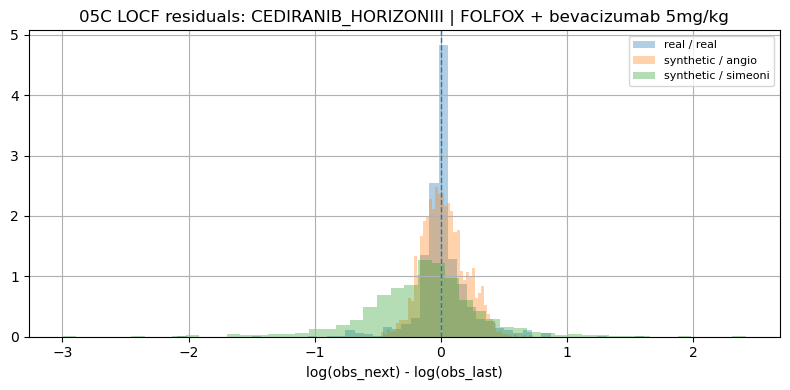

Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\plots\05C_locf_residual_compare_CEDIRANIB_HORIZONIII_FOLFOX_+_bevacizumab_5mg_kg.png


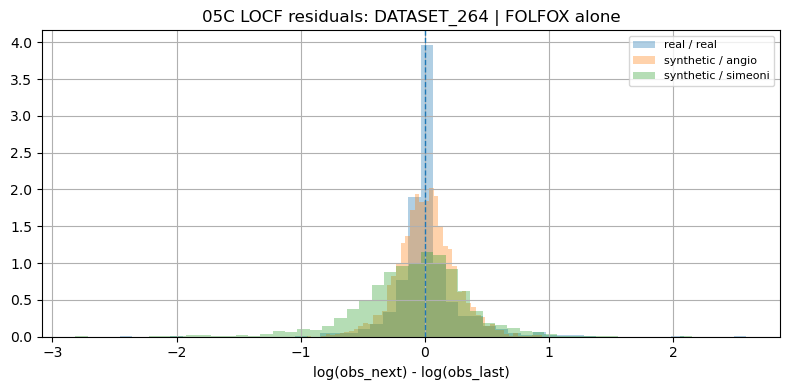

Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\plots\05C_locf_residual_compare_DATASET_264_FOLFOX_alone.png


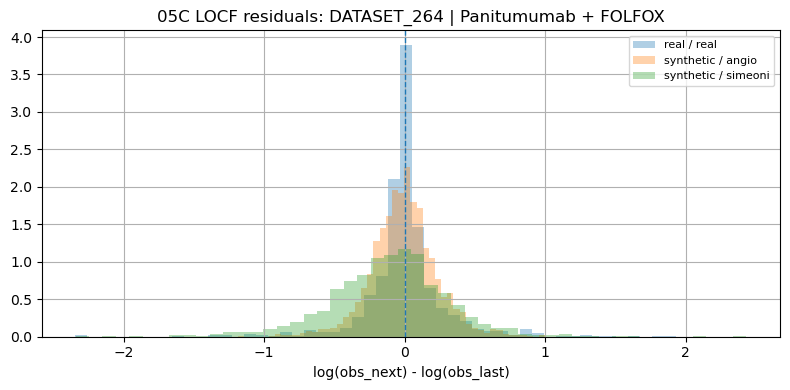

Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\plots\05C_locf_residual_compare_DATASET_264_Panitumumab_+_FOLFOX.png


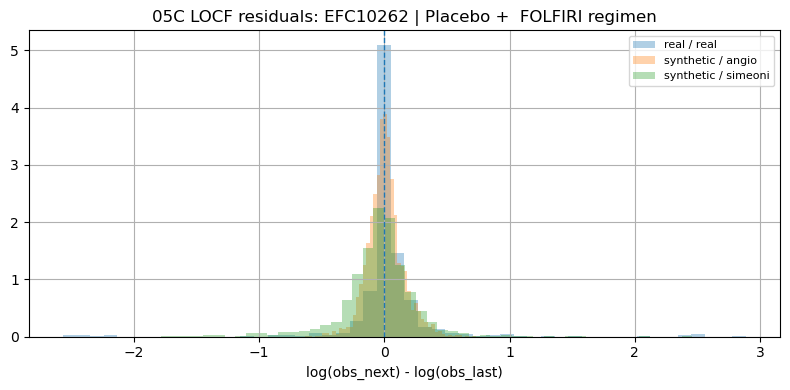

Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\plots\05C_locf_residual_compare_EFC10262_Placebo_+__FOLFIRI_regimen.png


In [39]:
# ---------------------------------------------------------------------
# Plot real-vs-05C synthetic LOCF residuals
# ---------------------------------------------------------------------

plot_strata = (
    locf_05C_summary[["study_id", "drug_signature", "arm"]]
    .drop_duplicates()
    .head(min(4, len(stratum_bundles)))
)

for _, row in plot_strata.iterrows():
    mask = (
        (locf_05C_compare["study_id"].astype(str) == str(row["study_id"]))
        & (locf_05C_compare["drug_signature"].astype(str) == str(row["drug_signature"]))
        & (locf_05C_compare["arm"].astype(str) == str(row["arm"]))
    )

    g = locf_05C_compare[mask]

    fig, ax = plt.subplots(figsize=(8, 4))

    for label, gg in g.groupby(["source", "simulator"]):
        name = " / ".join(label)
        ax.hist(
            gg["log_error"],
            bins=50,
            alpha=0.35,
            density=True,
            label=name,
        )

    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_title(f"05C LOCF residuals: {row['study_id']} | {row['arm']}")
    ax.set_xlabel("log(obs_next) - log(obs_last)")
    ax.legend(fontsize=8)

    fig.tight_layout()

    safe_study = str(row["study_id"]).replace(" ", "_").replace("/", "_")[:40]
    safe_arm = str(row["arm"]).replace(" ", "_").replace("/", "_")[:40]
    path = PLOT_DIR / f"05C_locf_residual_compare_{safe_study}_{safe_arm}.png"

    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", path)

In [40]:
# ---------------------------------------------------------------------
# Real-vs-05C synthetic summary comparison
# ---------------------------------------------------------------------

comparison_rows_05C = []

for bundle in stratum_bundles:
    real_df = bundle["real_summary"].copy()

    comparison_rows_05C.append(
        {
            "study_id": bundle["study_id"],
            "drug_signature": bundle["drug_signature"],
            "arm": bundle["arm"],
            "source": "real",
            "simulator": "real",
            "n": int(len(real_df)),
            "median_final_rel_sld": float(real_df["final_rel_sld"].median()),
            "median_min_rel_sld": float(real_df["min_rel_sld"].median()),
            "median_max_rel_sld": float(real_df["max_rel_sld"].median()),
            "frac_progression_or_growth": float((real_df["response_class"] == "progression_or_growth").mean()),
            "frac_response_or_shrinkage": float((real_df["response_class"] == "response_or_shrinkage").mean()),
            "frac_response_then_regrowth": float((real_df["response_class"] == "response_then_regrowth").mean()),
            "frac_stable_like": float((real_df["response_class"] == "stable_like").mean()),
        }
    )

for (study, drug, arm, simulator), g in synthetic_05C_summary.groupby(
    ["study_id", "drug_signature", "arm", "simulator"]
):
    comparison_rows_05C.append(
        {
            "study_id": study,
            "drug_signature": drug,
            "arm": arm,
            "source": "synthetic_05C",
            "simulator": simulator,
            "n": int(len(g)),
            "median_final_rel_sld": float(g["obs_final_rel_sld"].median()),
            "median_min_rel_sld": float(g["obs_min_rel_sld"].median()),
            "median_max_rel_sld": float(g["obs_max_rel_sld"].median()),
            "frac_progression_or_growth": float((g["obs_response_class"] == "progression_or_growth").mean()),
            "frac_response_or_shrinkage": float((g["obs_response_class"] == "response_or_shrinkage").mean()),
            "frac_response_then_regrowth": float((g["obs_response_class"] == "response_then_regrowth").mean()),
            "frac_stable_like": float((g["obs_response_class"] == "stable_like").mean()),
        }
    )

comparison_05C = pd.DataFrame(comparison_rows_05C)

comparison_05C_path = SYNTH_OUT_DIR / "05C_real_vs_locally_matched_synthetic_summary.csv"
comparison_05C.to_csv(comparison_05C_path, index=False)

display(comparison_05C.head(80))
print("Saved:", comparison_05C_path)

,study_id,drug_signature,arm,source,simulator,n,median_final_rel_sld,median_min_rel_sld,median_max_rel_sld,frac_progression_or_growth,frac_response_or_shrinkage,frac_response_then_regrowth,frac_stable_like
0,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,real,real,268,0.628506,0.520626,1.000000,0.018657,0.458955,0.324627,0.197761
1,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,real,real,190,0.618803,0.403973,1.000000,0.042105,0.389474,0.457895,0.110526
2,EFC10262,5-FU+IRINOTECAN+LEUCOVORIN+PLACEBO,Placebo + FOLFIRI regimen,real,real,190,0.947991,0.743277,1.000000,0.184211,0.184211,0.231579,0.400000
3,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFOX,real,real,188,0.566432,0.353407,1.000000,0.021277,0.430851,0.452128,0.095745
4,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,synthetic_05C,angio,600,0.458508,0.391714,1.000000,0.030000,0.453333,0.321667,0.195000
5,CEDIRANIB_HORIZONIII,FOLFOX + BEVACIZUMAB 5MG/KG,FOLFOX + bevacizumab 5mg/kg,synthetic_05C,simeoni,600,0.310822,0.255673,1.000000,0.030000,0.453333,0.321667,0.195000
6,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,synthetic_05C,angio,600,0.524976,0.381160,1.000000,0.041667,0.390000,0.458333,0.110000
7,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,FOLFOX alone,synthetic_05C,simeoni,600,0.285990,0.212264,1.000000,0.041667,0.390000,0.458333,0.110000
8,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFOX,synthetic_05C,angio,600,0.516346,0.358481,1.000000,0.030000,0.426667,0.448333,0.095000
9,DATASET_264,5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS...,Panitumumab + FOLFOX,synthetic_05C,simeoni,600,0.244216,0.170446,1.000000,0.030000,0.426667,0.448333,0.095000


Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\synthetic_data\05C_real_vs_locally_matched_synthetic_summary.csv


In [41]:
# ---------------------------------------------------------------------
# 05C grouped split by real template patient
# ---------------------------------------------------------------------

def grouped_split_by_template_05C(
    sims: list[dict],
    train_frac: float = 0.80,
    val_frac: float = 0.10,
    seed: int = 777,
) -> dict:
    rng = np.random.default_rng(seed)

    rows = []

    for i, s in enumerate(sims):
        rows.append(
            {
                "list_idx": i,
                "sim_id": int(s["sim_id"]),
                "study_id": s["study_id"],
                "drug_signature": s["drug_signature"],
                "arm": s["arm"],
                "simulator": s["simulator"],
                "template_patient_key": s["template_patient_key"],
            }
        )

    df = pd.DataFrame(rows)

    assert df["sim_id"].is_unique, "sim_id must be unique before grouped split."

    train_ids = []
    val_ids = []
    test_ids = []

    for keys, g in df.groupby(["study_id", "drug_signature", "arm", "simulator"]):
        templates_unique = g["template_patient_key"].drop_duplicates().to_numpy()
        rng.shuffle(templates_unique)

        n = len(templates_unique)
        n_train = max(1, int(train_frac * n))
        n_val = max(1, int(val_frac * n)) if n >= 10 else max(0, int(val_frac * n))

        train_templates = set(templates_unique[:n_train])
        val_templates = set(templates_unique[n_train:n_train + n_val])
        test_templates = set(templates_unique[n_train + n_val:])

        if len(test_templates) == 0 and len(val_templates) > 1:
            moved = list(val_templates)[-1]
            val_templates.remove(moved)
            test_templates.add(moved)

        train_ids.extend(g[g["template_patient_key"].isin(train_templates)]["sim_id"].tolist())
        val_ids.extend(g[g["template_patient_key"].isin(val_templates)]["sim_id"].tolist())
        test_ids.extend(g[g["template_patient_key"].isin(test_templates)]["sim_id"].tolist())

    split = {
        "train_sim_id": sorted(map(int, train_ids)),
        "val_sim_id": sorted(map(int, val_ids)),
        "test_sim_id": sorted(map(int, test_ids)),
    }

    # Safety checks.
    for k in split:
        assert len(split[k]) == len(set(split[k])), f"Duplicate IDs in {k}"

    all_ids = split["train_sim_id"] + split["val_sim_id"] + split["test_sim_id"]
    assert len(all_ids) == len(set(all_ids)), "Overlap between train/val/test splits."

    return split


grouped_split_05C = grouped_split_by_template_05C(
    all_05C_sims,
    seed=202607,
)

split_05C_path = SYNTH_OUT_DIR / "05C_grouped_template_train_val_test_split.json"

with open(split_05C_path, "w") as f:
    json.dump(grouped_split_05C, f, indent=2)

print("05C grouped split sizes:")
print(" train:", len(grouped_split_05C["train_sim_id"]))
print(" val:  ", len(grouped_split_05C["val_sim_id"]))
print(" test: ", len(grouped_split_05C["test_sim_id"]))
print(" total:", sum(len(v) for v in grouped_split_05C.values()))

print("Saved:", split_05C_path)

05C grouped split sizes:
 train: 3849
 val:   459
 test:  492
 total: 4800
Saved: C:\Users\Edoardo\Documents\EPFL\ml_redo\oncology-sbi-pkpd\outputs\notebook_05_selected_stratum_simulator_design\synthetic_data\05C_grouped_template_train_val_test_split.json


In [42]:
# ---------------------------------------------------------------------
# 05C export clean per-simulator SBI arrays
# ---------------------------------------------------------------------

def build_stratum_id_maps(sims: list[dict]) -> tuple[dict, dict]:
    strata = sorted(
        {
            str(s["study_id"]) + "||" + str(s["drug_signature"]) + "||" + str(s["arm"])
            for s in sims
        }
    )

    stratum_to_id = {s: i for i, s in enumerate(strata)}
    id_to_stratum = {i: s for s, i in stratum_to_id.items()}

    return stratum_to_id, id_to_stratum


stratum_to_id_05C, id_to_stratum_05C = build_stratum_id_maps(all_05C_sims)

print("05C stratum map:")
print(json.dumps(id_to_stratum_05C, indent=2))


def template_baseline_lookup_from_bundles() -> dict:
    lookup = {}

    for b in stratum_bundles:
        for tmpl in b["templates"]:
            lookup[tmpl["patient_key"]] = tmpl.get("baseline_sld_mm", np.nan)

    return lookup


baseline_lookup = template_baseline_lookup_from_bundles()


def export_05C_sbi_arrays_for_simulator(
    sims: list[dict],
    simulator: str,
    theta_names: list[str],
    grouped_split: dict,
    out_prefix: str = "05C_locally_matched_multistratum",
) -> dict:
    selected = [s for s in sims if s["simulator"] == simulator]

    if not selected:
        raise RuntimeError(f"No simulations found for simulator={simulator}")

    selected = sorted(selected, key=lambda s: int(s["sim_id"]))

    T_max = int(max(len(s["times"]) for s in selected))
    N = len(selected)

    x_obs = np.zeros((N, T_max, 3), dtype=np.float32)
    theta = np.zeros((N, len(theta_names)), dtype=np.float32)
    sim_id = np.zeros(N, dtype=np.int64)

    # Covariates:
    #   log baseline SLD
    #   duration in years
    #   n_scans / 25
    #   dose_confounded
    #   one-hot stratum indicators
    n_strata = len(stratum_to_id_05C)
    x_cov = np.zeros((N, 4 + n_strata), dtype=np.float32)

    cov_names = [
        "log_baseline_sld_mm",
        "duration_years",
        "n_scans_over_25",
        "dose_confounded",
    ] + [f"stratum_{i}" for i in range(n_strata)]

    metadata_rows = []

    for i, s in enumerate(selected):
        times = np.asarray(s["times"], dtype=float)
        obs_rel = np.asarray(s["obs_rel"], dtype=float)
        L = len(times)

        x_obs[i, :L, 0] = (times / 365.0).astype(np.float32)
        x_obs[i, :L, 1] = np.log(np.maximum(obs_rel, 1e-8)).astype(np.float32)
        x_obs[i, :L, 2] = 1.0

        for j, name in enumerate(theta_names):
            if name not in s["params"]:
                raise KeyError(f"Missing theta {name} for simulator {simulator}")
            theta[i, j] = float(s["params"][name])

        sid = int(s["sim_id"])
        sim_id[i] = sid

        baseline = baseline_lookup.get(s["template_patient_key"], np.nan)

        if not np.isfinite(baseline) or baseline <= 0:
            baseline = float(s["params"].get("v0", 1.0))

        stratum_key = str(s["study_id"]) + "||" + str(s["drug_signature"]) + "||" + str(s["arm"])
        stratum_id = stratum_to_id_05C[stratum_key]

        x_cov[i, 0] = np.log(max(float(baseline), 1e-8))
        x_cov[i, 1] = float(times[-1] / 365.0)
        x_cov[i, 2] = float(L / 25.0)
        x_cov[i, 3] = float(bool(s.get("dose_confounded", False)))
        x_cov[i, 4 + stratum_id] = 1.0

        metadata_rows.append(
            {
                "row_idx": i,
                "sim_id": sid,
                "simulator": simulator,
                "study_id": s["study_id"],
                "drug_signature": s["drug_signature"],
                "arm": s["arm"],
                "stratum_key": stratum_key,
                "stratum_id": stratum_id,
                "template_patient_key": s["template_patient_key"],
                "n_scans": int(L),
                "duration_days": float(times[-1]),
                "dose_confounded": bool(s.get("dose_confounded", False)),
                **{f"noise_{k}": v for k, v in s["noise_meta"].items()},
            }
        )

    metadata = pd.DataFrame(metadata_rows)

    assert metadata["sim_id"].is_unique
    assert np.isfinite(x_obs).all()
    assert np.isfinite(x_cov).all()
    assert np.isfinite(theta).all()

    sim_id_to_row = dict(zip(metadata["sim_id"].astype(int), metadata["row_idx"].astype(int)))

    split_row_idx = {}

    for split_name, ids in grouped_split.items():
        row_ids = [
            sim_id_to_row[int(sid)]
            for sid in ids
            if int(sid) in sim_id_to_row
        ]
        split_row_idx[split_name.replace("_sim_id", "_row_idx")] = row_ids
        split_row_idx[split_name] = [
            int(sid)
            for sid in ids
            if int(sid) in sim_id_to_row
        ]

    # Safety: no overlap in row indices.
    all_row_ids = (
        split_row_idx.get("train_row_idx", [])
        + split_row_idx.get("val_row_idx", [])
        + split_row_idx.get("test_row_idx", [])
    )
    assert len(all_row_ids) == len(set(all_row_ids)), f"Split overlap for {simulator}"

    npz_path = SYNTH_OUT_DIR / f"{out_prefix}_{simulator}_sbi_arrays_no_nan.npz"
    meta_path = SYNTH_OUT_DIR / f"{out_prefix}_{simulator}_metadata.csv"
    theta_path = SYNTH_OUT_DIR / f"{out_prefix}_{simulator}_theta.csv"
    split_path = SYNTH_OUT_DIR / f"{out_prefix}_{simulator}_split.json"

    np.savez_compressed(
        npz_path,
        x_obs=x_obs,
        x_cov=x_cov,
        theta=theta,
        theta_names=np.array(theta_names, dtype=object),
        sim_id=sim_id,
        time_scale=np.array([365.0], dtype=np.float32),
        cov_names=np.array(cov_names, dtype=object),
        stratum_keys=np.array([id_to_stratum_05C[i] for i in range(n_strata)], dtype=object),
    )

    metadata.to_csv(meta_path, index=False)

    theta_df = pd.DataFrame(theta, columns=theta_names)
    theta_df.insert(0, "sim_id", sim_id)
    theta_df.to_csv(theta_path, index=False)

    with open(split_path, "w") as f:
        json.dump(split_row_idx, f, indent=2)

    return {
        "simulator": simulator,
        "npz_path": str(npz_path),
        "metadata_path": str(meta_path),
        "theta_path": str(theta_path),
        "split_path": str(split_path),
        "x_obs_shape": list(x_obs.shape),
        "x_cov_shape": list(x_cov.shape),
        "theta_shape": list(theta.shape),
        "theta_names": theta_names,
        "cov_names": cov_names,
    }


SIMEONI_05C_THETA_NAMES = ["lam0", "lam1", "psi_g", "k_cyt", "k_tr", "v0"]

# For angio, k_cyt was fixed/removed from inference when exposure channels were confounded.
ANGIO_05C_THETA_NAMES = ["rho", "k_anti", "k_K_recovery", "K0_ratio", "v0"]

simeoni_05C_export = export_05C_sbi_arrays_for_simulator(
    all_05C_sims,
    simulator="simeoni",
    theta_names=SIMEONI_05C_THETA_NAMES,
    grouped_split=grouped_split_05C,
)

angio_05C_export = export_05C_sbi_arrays_for_simulator(
    all_05C_sims,
    simulator="angio",
    theta_names=ANGIO_05C_THETA_NAMES,
    grouped_split=grouped_split_05C,
)

print("05C Simeoni export:")
print(json.dumps(simeoni_05C_export, indent=2))

print("\n05C Angio export:")
print(json.dumps(angio_05C_export, indent=2))

05C stratum map:
{
  "0": "CEDIRANIB_HORIZONIII||FOLFOX + BEVACIZUMAB 5MG/KG||FOLFOX + bevacizumab 5mg/kg",
  "1": "DATASET_264||5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS+LEUCOVORIN+OXALIPLATIN+PANIT.||Panitumumab + FOLFOX",
  "2": "DATASET_264||5-FLUOROURACIL BOLUS+5-FLUOROURACIL CONTINUOUS+LEUCOVORIN+OXALIPLATIN||FOLFOX alone",
  "3": "EFC10262||5-FU+IRINOTECAN+LEUCOVORIN+PLACEBO||Placebo +  FOLFIRI regimen"
}
05C Simeoni export:
{
  "simulator": "simeoni",
  "npz_path": "C:\\Users\\Edoardo\\Documents\\EPFL\\ml_redo\\oncology-sbi-pkpd\\outputs\\notebook_05_selected_stratum_simulator_design\\synthetic_data\\05C_locally_matched_multistratum_simeoni_sbi_arrays_no_nan.npz",
  "metadata_path": "C:\\Users\\Edoardo\\Documents\\EPFL\\ml_redo\\oncology-sbi-pkpd\\outputs\\notebook_05_selected_stratum_simulator_design\\synthetic_data\\05C_locally_matched_multistratum_simeoni_metadata.csv",
  "theta_path": "C:\\Users\\Edoardo\\Documents\\EPFL\\ml_redo\\oncology-sbi-pkpd\\outputs\\notebook_0

In [43]:
# ---------------------------------------------------------------------
# 05C final checks
# ---------------------------------------------------------------------

def quick_export_check(export: dict):
    meta = pd.read_csv(export["metadata_path"])
    th = pd.read_csv(export["theta_path"])
    arr = np.load(export["npz_path"], allow_pickle=True)

    print("\nChecking:", export["simulator"])
    print(" metadata:", meta.shape)
    print(" theta:", th.shape)
    print(" x_obs:", arr["x_obs"].shape)
    print(" x_cov:", arr["x_cov"].shape)
    print(" theta array:", arr["theta"].shape)

    assert meta["sim_id"].is_unique
    assert th["sim_id"].is_unique
    assert arr["x_obs"].shape[0] == len(meta)
    assert arr["theta"].shape[0] == len(meta)
    assert arr["x_cov"].shape[0] == len(meta)
    assert np.isfinite(arr["x_obs"]).all()
    assert np.isfinite(arr["x_cov"]).all()
    assert np.isfinite(arr["theta"]).all()

    print(" OK")


quick_export_check(simeoni_05C_export)
quick_export_check(angio_05C_export)


Checking: simeoni
 metadata: (2400, 18)
 theta: (2400, 7)
 x_obs: (2400, 25, 3)
 x_cov: (2400, 8)
 theta array: (2400, 6)
 OK

Checking: angio
 metadata: (2400, 18)
 theta: (2400, 6)
 x_obs: (2400, 25, 3)
 x_cov: (2400, 8)
 theta array: (2400, 5)
 OK


In [44]:
# ---------------------------------------------------------------------
# Save 05C conclusion
# ---------------------------------------------------------------------

conclusion_05C = {
    "n_strata": int(len(stratum_bundles)),
    "n_synthetic_total": int(len(all_05C_sims)),
    "n_synthetic_by_simulator": synthetic_05C_summary["simulator"].value_counts().to_dict(),
    "sim_id_unique": bool(synthetic_05C_summary["sim_id"].is_unique),
    "synthetic_summary_path": str(synthetic_05C_summary_path),
    "selection_audit_path": str(selection_05C_audit_path),
    "locf_residual_summary_path": str(locf_05C_summary_path),
    "real_vs_synthetic_summary_path": str(comparison_05C_path),
    "grouped_split_path": str(split_05C_path),
    "simeoni_export": simeoni_05C_export,
    "angio_export": angio_05C_export,
    "recommendation": (
        "Use the 05C exports for notebook 06. Start with angio-only NPE using "
        "the 05C angio array and its grouped split. Compare parameter recovery "
        "and posterior predictive calibration before training mixed-family models."
    ),
}

conclusion_05C_path = OUT_DIR / "05C_local_dynamics_tuned_sbi_prep_conclusion.json"

with open(conclusion_05C_path, "w") as f:
    json.dump(conclusion_05C, f, indent=2, default=str)

print(json.dumps(conclusion_05C, indent=2, default=str)[:10000])
print("Saved:", conclusion_05C_path)

{
  "n_strata": 4,
  "n_synthetic_total": 4800,
  "n_synthetic_by_simulator": {
    "simeoni": 2400,
    "angio": 2400
  },
  "sim_id_unique": true,
  "synthetic_summary_path": "C:\\Users\\Edoardo\\Documents\\EPFL\\ml_redo\\oncology-sbi-pkpd\\outputs\\notebook_05_selected_stratum_simulator_design\\synthetic_data\\05C_locally_matched_synthetic_summary.csv",
  "selection_audit_path": "C:\\Users\\Edoardo\\Documents\\EPFL\\ml_redo\\oncology-sbi-pkpd\\outputs\\notebook_05_selected_stratum_simulator_design\\synthetic_data\\05C_local_selection_audit.csv",
  "locf_residual_summary_path": "C:\\Users\\Edoardo\\Documents\\EPFL\\ml_redo\\oncology-sbi-pkpd\\outputs\\notebook_05_selected_stratum_simulator_design\\synthetic_data\\05C_real_vs_synthetic_locf_residual_summary.csv",
  "real_vs_synthetic_summary_path": "C:\\Users\\Edoardo\\Documents\\EPFL\\ml_redo\\oncology-sbi-pkpd\\outputs\\notebook_05_selected_stratum_simulator_design\\synthetic_data\\05C_real_vs_locally_matched_synthetic_summary.csv",